In [1]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Font size settings for figures
mpl.rcParams.update({
    "font.size": 14,              # base font size
    "axes.titlesize": 16,         # title font
    "axes.labelsize": 14,         # x/y label font
    "xtick.labelsize": 12,        # x-tick labels
    "ytick.labelsize": 12,        # y-tick labels
    "legend.fontsize": 12,        # legend text
    "lines.linewidth": 2,         # line thickness
    "axes.linewidth": 1.2,        # axis border thickness
})

# Function to make annotating data on figures easier
def annotate_final_values(ax, x, y_values, labels, min_sep_frac=0.1):
    """
    Adds annotations at the final time point of each y-series with spacing done in axis-fraction units.

    Parameters:
        ax: matplotlib Axes object
        x: time points (1D array)
        y_values: list of y-arrays
        labels: list of label strings
        min_sep_frac: minimum spacing between annotations in axis fraction (0.03 = 3% of y-axis height)
    """
    final_x = x[-1]
    final_ys = [y[-1] for y in y_values]
    y_min, y_max = ax.get_ylim()

    # Convert y-values to axis-fraction space
    y_fracs = [(y - y_min) / (y_max - y_min) for y in final_ys]

    # Sort and apply minimum spacing in axis-fraction space
    sorted_indices = np.argsort(y_fracs)
    new_frac_positions = {}
    last_frac = None
    for idx in sorted_indices:
        frac = y_fracs[idx]
        if last_frac is None:
            new_frac_positions[idx] = frac
        else:
            new_frac_positions[idx] = max(frac, last_frac + min_sep_frac)
        last_frac = new_frac_positions[idx]

    # Clamp to [0,1] and convert back to data coordinates
    for idx in range(len(y_values)):
        orig_y = final_ys[idx]
        frac_y = min(new_frac_positions[idx], 0.98)  # avoid going out of bounds
        adjusted_y = y_min + frac_y * (y_max - y_min)

        ax.annotate(f"{labels[idx]}\n{orig_y:.0f}",
                    xy=(final_x, orig_y),
                    xytext=(final_x + 1, adjusted_y),
                    textcoords='data',
                    fontsize=8,
                    va='center',
                    ha='left',
                    arrowprops=dict(arrowstyle='->', lw=0.5),
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5))

# ODE Model Summaries

---

## 1. Unregulated cell count model predicts mutant colonies have more cells than WT

**Hypothesis**
Because symmetric NB divisions generate additional proliferative neuroblasts, we hypothesized that mutant lineages with symmetric divisions (mudmut and nanobody) would outgrow WT lineages, which divide strictly asymmetrically.

**Methods**
We implemented a simple ODE model tracking only cell counts, without regulation. The fraction of symmetric divisions was set to 0 for WT and 15% for mutants (mudmut and nanobody).

**Results**
Mutant simulations consistently yielded higher lineage cell counts than WT simulations.

**Conclusions**
This trivial result confirms that symmetric divisions alone are sufficient to expand NB lineages. Since experimental data show mutants have fewer cells than WT, additional regulation must be acting on mutant lineages.

In [47]:
def neuroblast_model(t, y, params): # from ode_models_2025-08-21_divisionrateonly.ipynb
    N_NB, N_GMC, N_ImNeuron, N_MatNeuron = y
    k_NB, k_GMC, k_Neuron, sym_frac = params  # Division and maturation rates

    # Neuroblast divisions
    sym_divs = sym_frac * k_NB * N_NB
    asym_divs = (1 - sym_frac) * k_NB * N_NB

    # ODEs
    dN_NB = sym_divs
    dN_GMC = asym_divs - k_GMC * N_GMC
    dN_ImNeuron = 2 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
    dN_MatNeuron = k_Neuron * N_ImNeuron

    return [dN_NB, dN_GMC, dN_ImNeuron, dN_MatNeuron]

WT simulation

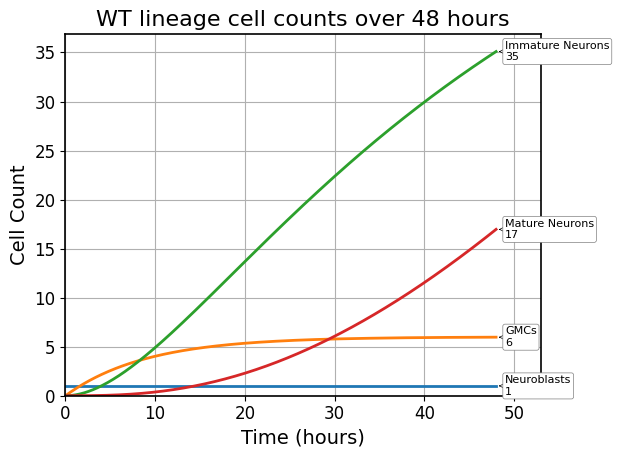

In [48]:
# Parameter value assignment
k_NB = 1/1.5
k_GMC = 1/9.0
k_Neuron = 1/48

# Parameters: [k_NB, k_GMC, k_Neuron, sym_frac]
params = [
    k_NB,    # Neuroblast divides every 1.5 hrs
    k_GMC,   # GMC divides every 9 hrs
    k_Neuron,   # Immature neurons mature every 48 hrs
    0.0      # 0% symmetric NB divisions for WT
]

# Initial conditions: [N_NB, N_GMC, N_ImNeuron, N_MatNeuron]
y0 = [1, 0, 0, 0]

# Time span
t_span = [0, 48]  # simulate 48 hours
t_eval = np.linspace(*t_span, 500)

# Solve ODE
sol = solve_ivp(neuroblast_model, t_span, y0, t_eval=t_eval, args=(params,))

# Plotting
fig, ax = plt.subplots()

labels = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
y_data = [sol.y[0], sol.y[1], sol.y[2], sol.y[3]]

for y, label in zip(y_data, labels):
    ax.plot(sol.t, y, label=label)

ax.set_xlim(0, sol.t[-1] + 5)
ax.set_ylim(bottom=0)
annotate_final_values(ax, sol.t, y_data, labels)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("WT lineage cell counts over 48 hours")
ax.grid()
plt.tight_layout()
plt.show()

mudmut/nanobody simulation

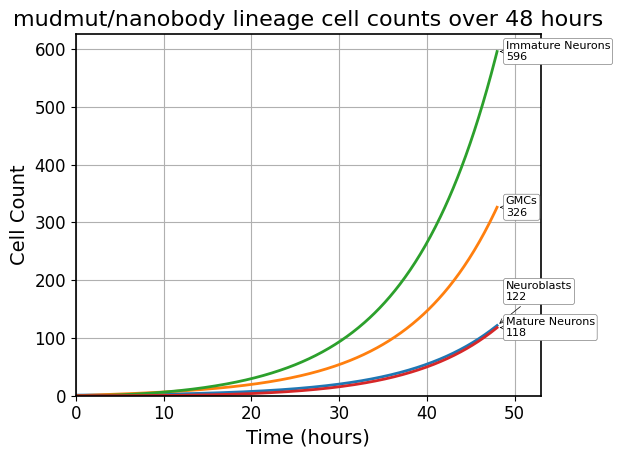

In [49]:
# Parameters: [k_NB, k_GMC, k_Neuron, sym_frac]
params = [
    k_NB,    # Neuroblast divides every 1.5 hrs
    k_GMC,   # GMC divides every 9 hrs
    k_Neuron,   # Immature neurons mature every 48 hrs
    0.15      # 15% symmetric NB divisions for WT
]

# Initial conditions: [N_NB, N_GMC, N_ImNeuron, N_MatNeuron]
y0 = [1, 0, 0, 0]

# Time span
t_span = [0, 48]  # simulate 48 hours
t_eval = np.linspace(*t_span, 500)

# Solve ODE
sol = solve_ivp(neuroblast_model, t_span, y0, t_eval=t_eval, args=(params,))

# Plotting
fig, ax = plt.subplots()

labels = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
y_data = [sol.y[0], sol.y[1], sol.y[2], sol.y[3]]

for y, label in zip(y_data, labels):
    ax.plot(sol.t, y, label=label)

ax.set_xlim(0, sol.t[-1] + 5)
ax.set_ylim(bottom=0)
annotate_final_values(ax, sol.t, y_data, labels)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("mudmut/nanobody lineage cell counts over 48 hours")
ax.grid()
plt.tight_layout()
plt.show()

---

# 2. NB self-regulation of division rate can invert the WT vs. mutant cell-count relationship

**Hypothesis**
We hypothesized that negative feedback on NB growth or division could explain why mutants produce fewer cells than WT.

**Methods**
We extended the unregulated count model to include negative feedback of cell count on NB growth rate. We systematically tested feedback driven by each cell type individually and all combinations of cell types except NBs themselves. Simulations were run for 48 hours.

**Results**
Only negative feedback of NB growth rate by NB count reproduced experimental trends: mutants with 15% symmetric divisions produced fewer cells than WT, while WT still achieved realistic colony sizes (>20 cells). Steep feedback (Hill coefficient ≥ 3) was required.

**Conclusions**
This model suggests that inhibition contingent on NB–NB interactions are sufficient inhibit NB growth. Alternatively, regulation could depend on NB volume, which this count-only model cannot capture. Cell volumes differ greatly between WT and mutant NBs, motivating exploration of volume-dependent dynamics.

GMC Counterexample

In [57]:
def neuroblast_model_GMC_represses_NB_count(t, y, params):
    """
    Simple count model where GMC abundance represses NB division rate.

    State vector:
        y = [N_NB, N_GMC, N_ImNeuron, N_MatNeuron]

    Parameters (in order):
        k_NB_max      : float   # maximum NB division rate (1/hr)
        k_GMC         : float   # GMC division rate (1/hr)
        k_Neuron      : float   # immature neuron maturation rate (1/hr)
        K_GMC_to_NB   : float   # half-max constant for GMC -> NB repression (cells)
        n_gmc         : float   # Hill coefficient for GMC -> NB repression
        sym_frac      : float   # fraction of NB divisions that are symmetric (unitless)

    ODEs:
        sym_divs  = sym_frac * k_NB_eff * N_NB
        asym_divs = (1 - sym_frac) * k_NB_eff * N_NB

        dN_NB        = sym_divs
        dN_GMC       = asym_divs - k_GMC * N_GMC
        dN_ImNeuron  = 2 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
        dN_MatNeuron = k_Neuron * N_ImNeuron
    """
    N_NB, N_GMC, N_ImNeuron, N_MatNeuron = y
    k_NB_max, k_GMC, k_Neuron, K_GMC_to_NB, n_gmc, sym_frac = params

    # Guard against negatives / zeros in Hill terms
    N_GMC_pos = max(N_GMC, 0.0)
    K_pos     = max(K_GMC_to_NB, 1e-12)
    n_pos     = max(n_gmc, 1e-12)

    # GMC → NB repression (decreasing Hill)
    k_NB_eff = k_NB_max * (K_pos**n_pos) / (K_pos**n_pos + N_GMC_pos**n_pos)

    # Partition NB divisions
    sym_divs  = sym_frac * k_NB_eff * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB_eff * N_NB

    # ODEs
    dN_NB        = sym_divs
    dN_GMC       = asym_divs - k_GMC * N_GMC
    dN_ImNeuron  = 2.0 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
    dN_MatNeuron = k_Neuron * N_ImNeuron

    return [dN_NB, dN_GMC, dN_ImNeuron, dN_MatNeuron]

WT Simulation

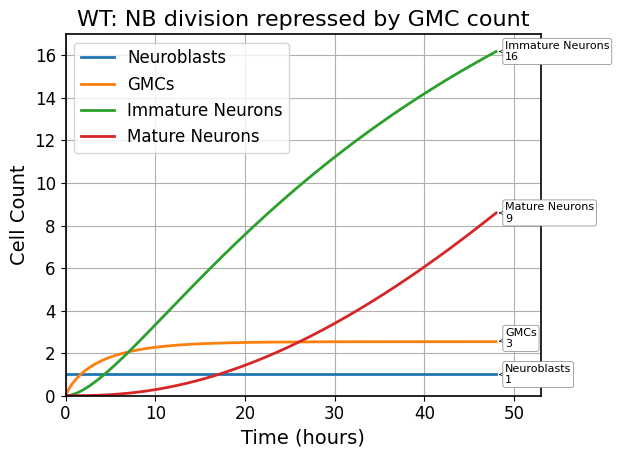

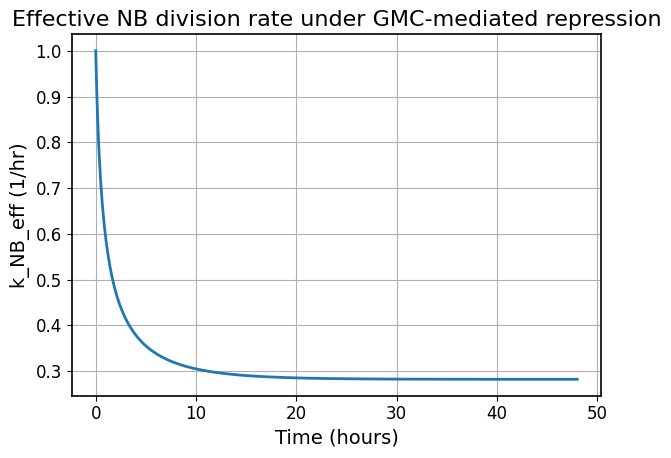

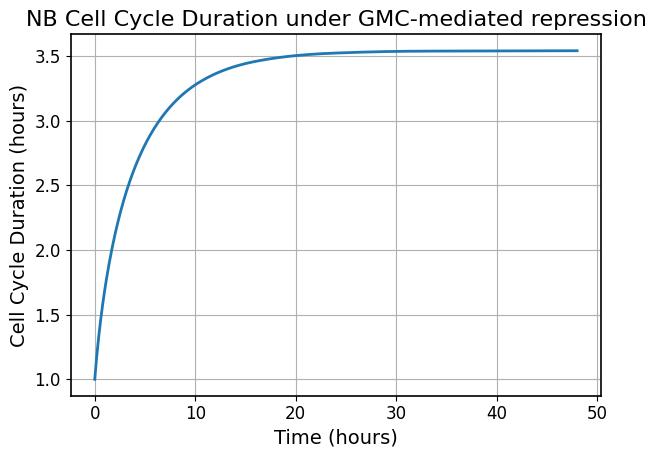

In [100]:
# --- Parameters consistent with earlier choices ---
k_NB_max    = 1     # max NB division rate: 1.15 per hour
k_GMC       = 1/9.0    # avg GMC divides every ~9 h
k_Neuron    = 1/48.0   # avg neuron maturation ~48 h
K_GMC_to_NB = 1.0      # half-max GMC count for repression
n_gmc       = 1        # MM-like repression
sym_frac    = 0.0      # WT: asymmetric

params = [k_NB_max, k_GMC, k_Neuron, K_GMC_to_NB, n_gmc, sym_frac]

# --- Initial condition and integration grid ---
y0 = [1, 0, 0, 0]   # start with 1 NB, no other cells
t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(
    neuroblast_model_GMC_represses_NB_count,
    t_span, y0, t_eval=t_eval, args=(params,)
)

# --- Plot cell counts ---
fig, ax = plt.subplots()
labels = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
series = [sol.y[0], sol.y[1], sol.y[2], sol.y[3]]

for s, lab in zip(series, labels):
    ax.plot(sol.t, s, label=lab)

ax.set_xlim(0, sol.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol.t, series, labels)  # optional helper
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("WT: NB division repressed by GMC count")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# --- Visualize k_NB_eff over time ---
N_GMC = sol.y[1]
if K_GMC_to_NB > 0:
    k_NB_eff = k_NB_max * (K_GMC_to_NB**n_gmc) / (K_GMC_to_NB**n_gmc + N_GMC**n_gmc)
else:
    k_NB_eff = k_NB_max * np.ones_like(N_GMC)

fig, ax = plt.subplots()
ax.plot(sol.t, k_NB_eff)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("k_NB_eff (1/hr)")
ax.set_title("Effective NB division rate under GMC-mediated repression")
ax.grid()
plt.tight_layout()
plt.show()

# --- Visualize NB cell cycle duration over time ---
cell_cycle_duration = np.where(k_NB_eff > 0, 1.0 / k_NB_eff, np.nan)

fig, ax = plt.subplots()
ax.plot(sol.t, cell_cycle_duration)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Cycle Duration (hours)")
ax.set_title("NB Cell Cycle Duration under GMC-mediated repression")
ax.grid()
plt.tight_layout()
plt.show()

mudmut/nanobody simulation

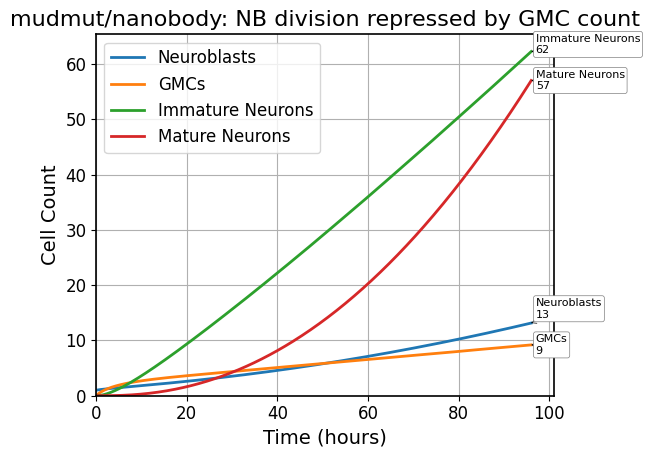

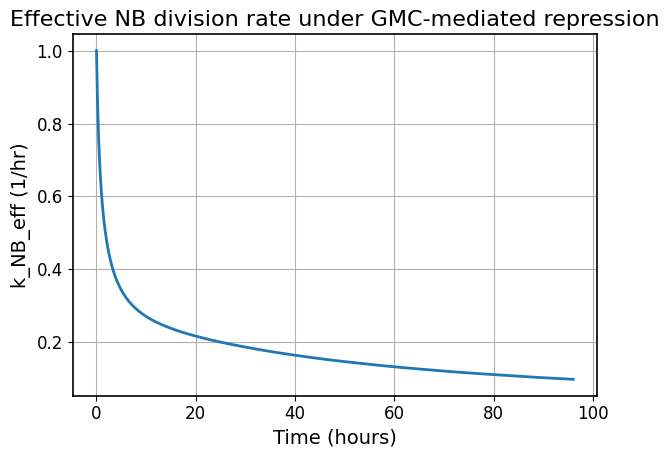

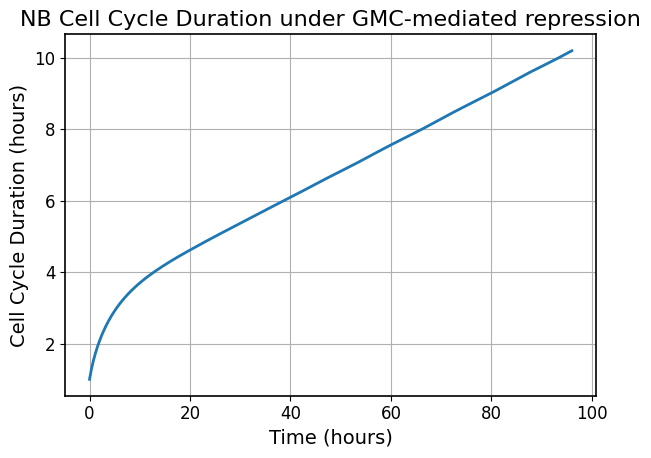

In [101]:
# --- Parameters consistent with earlier choices ---
sym_frac    = 0.15     # mudmut

params = [k_NB_max, k_GMC, k_Neuron, K_GMC_to_NB, n_gmc, sym_frac]

# --- Initial condition and integration grid ---
y0 = [1, 0, 0, 0]   # start with 1 NB, no other cells
t_span = [0, 96]
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(
    neuroblast_model_GMC_represses_NB_count,
    t_span, y0, t_eval=t_eval, args=(params,)
)

# --- Plot cell counts ---
fig, ax = plt.subplots()
labels = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
series = [sol.y[0], sol.y[1], sol.y[2], sol.y[3]]

for s, lab in zip(series, labels):
    ax.plot(sol.t, s, label=lab)

ax.set_xlim(0, sol.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol.t, series, labels)  # optional helper
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("mudmut/nanobody: NB division repressed by GMC count")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# --- Visualize k_NB_eff over time ---
N_GMC = sol.y[1]
if K_GMC_to_NB > 0:
    k_NB_eff = k_NB_max * (K_GMC_to_NB**n_gmc) / (K_GMC_to_NB**n_gmc + N_GMC**n_gmc)
else:
    k_NB_eff = k_NB_max * np.ones_like(N_GMC)

fig, ax = plt.subplots()
ax.plot(sol.t, k_NB_eff)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("k_NB_eff (1/hr)")
ax.set_title("Effective NB division rate under GMC-mediated repression")
ax.grid()
plt.tight_layout()
plt.show()

# --- Visualize NB cell cycle duration over time ---
cell_cycle_duration = np.where(k_NB_eff > 0, 1.0 / k_NB_eff, np.nan)

fig, ax = plt.subplots()
ax.plot(sol.t, cell_cycle_duration)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Cycle Duration (hours)")
ax.set_title("NB Cell Cycle Duration under GMC-mediated repression")
ax.grid()
plt.tight_layout()
plt.show()

NB-NB Point

In [65]:
def neuroblast_model_NB_self_repression(t, y, params):
    """
    Model where NB count represses NB division (self-repression) via a decreasing Hill function.

    State vector:
        y = [N_NB, N_GMC, N_ImNeuron, N_MatNeuron]

    Parameters (in order):
        k_NB_max         : float   # maximum NB division rate (1/hr)
        k_GMC            : float   # GMC division rate (1/hr)
        k_Neuron         : float   # immature neuron maturation rate (1/hr)
        K_NB_self        : float   # half-max constant for NB -> NB repression (cells)
        n_nb             : float   # Hill coefficient for NB -> NB repression
        sym_frac         : float   # fraction of NB divisions that are symmetric (unitless)

    ODEs:
        sym_divs  = sym_frac * k_NB_eff * N_NB
        asym_divs = (1 - sym_frac) * k_NB_eff * N_NB

        dN_NB        = sym_divs
        dN_GMC       = asym_divs - k_GMC * N_GMC
        dN_ImNeuron  = 2 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
        dN_MatNeuron = k_Neuron * N_ImNeuron
    """
    N_NB, N_GMC, N_ImNeuron, N_MatNeuron = y
    k_NB_max, k_GMC, k_Neuron, K_NB_self, n_nb, sym_frac = params

    # Guard against invalid values
    N_NB_pos = max(N_NB, 0.0)
    K_pos    = max(K_NB_self, 1e-12)
    n_pos    = max(n_nb, 1e-12)

    # Self-repression of NB division via decreasing Hill
    k_NB_eff = k_NB_max * (K_pos**n_pos) / (K_pos**n_pos + N_NB_pos**n_pos)

    # Partition NB divisions
    sym_divs  = sym_frac * k_NB_eff * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB_eff * N_NB

    # ODEs
    dN_NB        = sym_divs
    dN_GMC       = asym_divs - k_GMC * N_GMC
    dN_ImNeuron  = 2.0 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
    dN_MatNeuron = k_Neuron * N_ImNeuron

    return [dN_NB, dN_GMC, dN_ImNeuron, dN_MatNeuron]

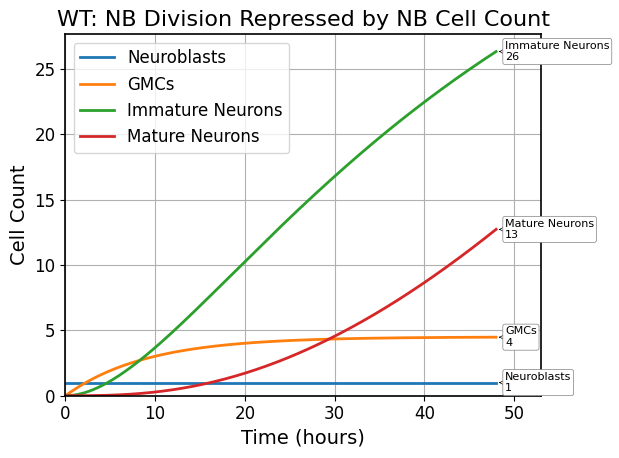

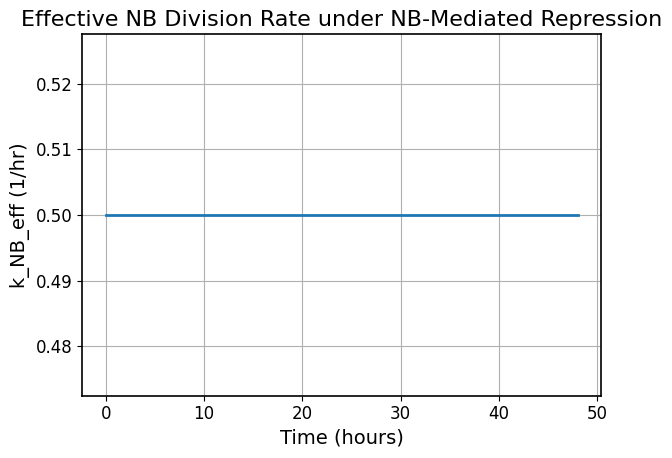

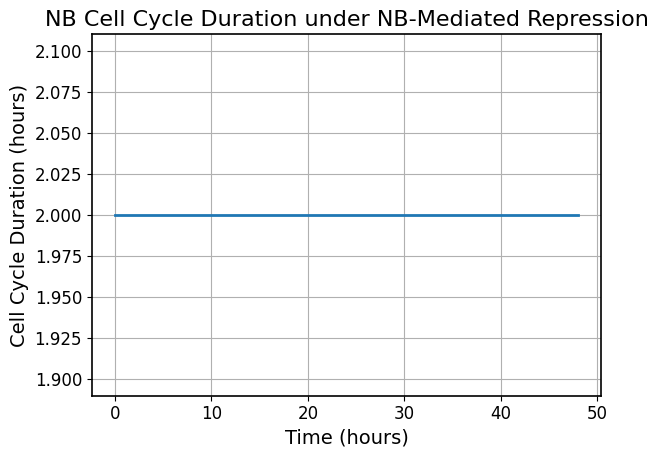

In [102]:
# --- Parameters consistent with earlier choices ---
k_NB_max    = 1.        # max NB division rate: 1 every 52 minutes
k_GMC       = 1 / 9.0   # avg GMC divides every ~9 h
k_Neuron    = 1 / 48.0  # avg neuron maturation ~48 h
K_NB_to_NB  = 1         # half-max NB count for repression
n_NB        = 3         # Hill coefficient (steepness)
sym_frac    = 0.0       # WT: asymmetric

params = [k_NB_max, k_GMC, k_Neuron, K_NB_to_NB, n_NB, sym_frac]

# --- Initial condition and integration grid ---
y0 = [1, 0, 0, 0]   # start with 1 NB, no other cells
t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ODE ---
sol = solve_ivp(
    neuroblast_model_NB_self_repression,
    t_span, y0, t_eval=t_eval, args=(params,)
)

# --- Plot cell counts with annotations ---
fig, ax = plt.subplots()
labels = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
series = [sol.y[0], sol.y[1], sol.y[2], sol.y[3]]

for s, lab in zip(series, labels):
    ax.plot(sol.t, s, label=lab)

ax.set_xlim(0, sol.t[-1] + 5)
ax.set_ylim(bottom=0)
annotate_final_values(ax, sol.t, series, labels)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("WT: NB Division Repressed by NB Cell Count")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# --- Visualize k_NB_eff over time ---
N_NB = sol.y[0]
k_NB_eff = k_NB_max * (K_NB_to_NB**n_NB) / (K_NB_to_NB**n_NB + N_NB**n_NB)

fig, ax = plt.subplots()
ax.plot(sol.t, k_NB_eff)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("k_NB_eff (1/hr)")
ax.set_title("Effective NB Division Rate under NB-Mediated Repression")
ax.grid()
plt.tight_layout()
plt.show()

# --- Visualize NB Cell Cycle Duration over time ---
cell_cycle_duration = np.where(k_NB_eff > 0, 1.0 / k_NB_eff, np.nan)

fig, ax = plt.subplots()
ax.plot(sol.t, cell_cycle_duration)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Cycle Duration (hours)")
ax.set_title("NB Cell Cycle Duration under NB-Mediated Repression")
ax.grid()
plt.tight_layout()
plt.show()

mudmut/nanobody simulation

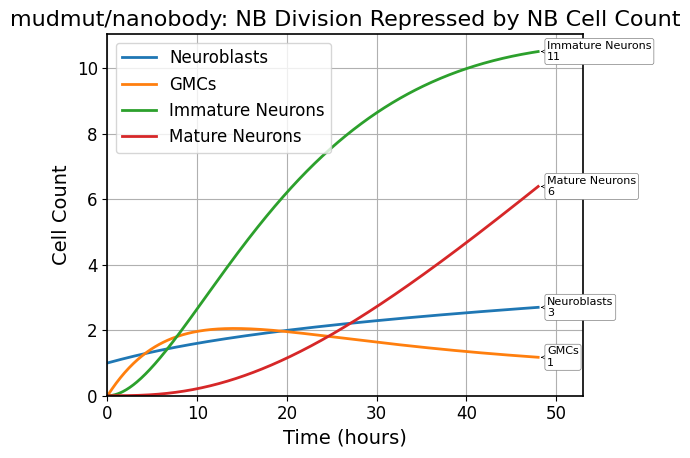

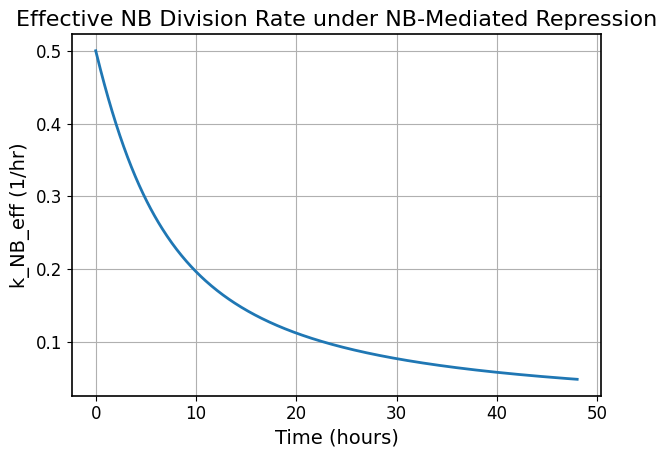

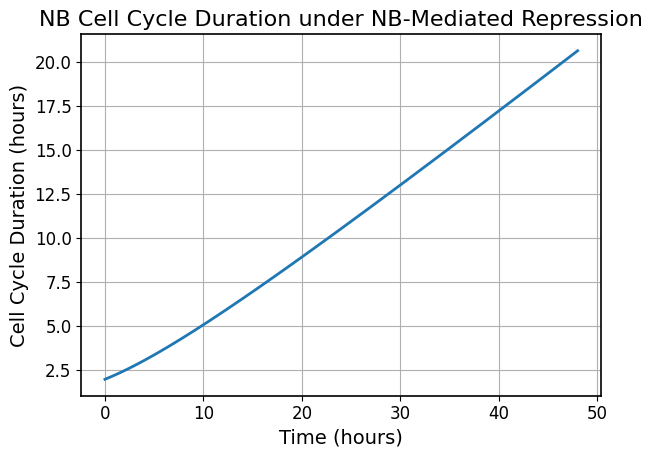

In [103]:
sym_frac    = 0.15       # mudmut/nanobody: asymmetric

params = [k_NB_max, k_GMC, k_Neuron, K_NB_to_NB, n_NB, sym_frac]

# --- Initial condition and integration grid ---
y0 = [1, 0, 0, 0]   # start with 1 NB, no other cells
t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ODE ---
sol = solve_ivp(
    neuroblast_model_NB_self_repression,
    t_span, y0, t_eval=t_eval, args=(params,)
)

# --- Plot cell counts with annotations ---
fig, ax = plt.subplots()
labels = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
series = [sol.y[0], sol.y[1], sol.y[2], sol.y[3]]

for s, lab in zip(series, labels):
    ax.plot(sol.t, s, label=lab)

ax.set_xlim(0, sol.t[-1] + 5)
ax.set_ylim(bottom=0)
annotate_final_values(ax, sol.t, series, labels)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("mudmut/nanobody: NB Division Repressed by NB Cell Count")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# --- Visualize k_NB_eff over time ---
N_NB = sol.y[0]
k_NB_eff = k_NB_max * (K_NB_to_NB**n_NB) / (K_NB_to_NB**n_NB + N_NB**n_NB)

fig, ax = plt.subplots()
ax.plot(sol.t, k_NB_eff)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("k_NB_eff (1/hr)")
ax.set_title("Effective NB Division Rate under NB-Mediated Repression")
ax.grid()
plt.tight_layout()
plt.show()

# --- Visualize NB Cell Cycle Duration over time ---
cell_cycle_duration = np.where(k_NB_eff > 0, 1.0 / k_NB_eff, np.nan)

fig, ax = plt.subplots()
ax.plot(sol.t, cell_cycle_duration)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Cycle Duration (hours)")
ax.set_title("NB Cell Cycle Duration under NB-Mediated Repression")
ax.grid()
plt.tight_layout()
plt.show()

---

## 3. Unregulated volume-dependent division model predicts mutants still outgrow WT

**Hypothesis**
We hypothesized that even if neuroblast (NB) division is constrained by cell volume, unregulated mutants would still produce more cells than WT.

**Methods**
We implemented an ODE model tracking cell counts and volumes. NB division followed a saturating power-law (“sizer”) function:

$k_{NB} = k_{\max} \cdot \min\!\left(1, \left(\frac{\bar{V}{NB}}{V{\text{thresh,NB}}}\right)^n\right),$

where $\bar{V}{NB}$ is the average NB volume, $V{\text{thresh,NB}}$ is the division threshold, and n controls the steepness of the transition. Division rate was set to zero if the average NB volume was below a floor volume. GMCs followed an analogous rule with their own threshold and floor.

We calibrate parameters to reproduce WT lineage dynamics. We simulated mutant conditions with 15% symmetric divisions (mudmut) or 15% symmetric divisions plus reduced NB growth rate (nanobody, 80% of WT).

**Results**
Both mudmut and nanobody simulations yielded higher cell counts than WT, despite the growth-rate reduction in nanobody lineages.

**Conclusions**
Volume-dependent division alone is insufficient to explain experimental results. Additional regulation is needed to constrain NB proliferation in mutants, motivating models in which growth rate is explicitly sensitive to NB volume.

In [ ]:
def neuroblast_model_no_feedback_satpow(t, y, params):
    """
    No parameter feedback on NB size.
    Division uses saturating power law:
        k = k_max * min(1, (Vbar / V_thresh)^n)
    Floors: NB uses V_floor_NB; GMC uses optional V_floor_GMC.
    """
    (N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat) = y

    (g_NB, g_GMC, k_Neuron, sym_frac,
     V_thresh_NB, V_thresh_GMC,
     k_max_NB, k_max_GMC, n,
     V_floor_NB, V_floor_GMC) = params

    # Averages
    Vavg_NB  = V_NB / N_NB if N_NB  > 0 else 0.0
    Vavg_GMC = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_Im  = V_Im  / N_Im  if N_Im  > 0 else 0.0

    def satpow_rate(Vbar, Vthresh, kmax, n):
        if Vbar <= 0 or Vthresh <= 0: return 0.0
        r = (Vbar / Vthresh) ** n
        return kmax * (1.0 if r >= 1.0 else r)

    # Division hazards (with floors)
    k_NB  = satpow_rate(Vavg_NB,  V_thresh_NB,  k_max_NB,  n)  if (N_NB  > 0 and Vavg_NB  >= V_floor_NB)  else 0.0
    k_GMC = satpow_rate(Vavg_GMC, V_thresh_GMC, k_max_GMC, n)  if (N_GMC > 0 and Vavg_GMC >= V_floor_GMC) else 0.0

    # Fluxes
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # ODEs
    dN_NB = sym_divs
    dV_NB = g_NB * N_NB - 0.2 * asym_divs * Vavg_NB

    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = g_GMC * N_GMC + 0.2 * asym_divs * Vavg_NB - k_GMC * N_GMC * Vavg_GMC

    dN_Im   = 2.0 * k_GMC * N_GMC - k_Neuron * N_Im
    dV_Im   = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_Im * Vavg_Im

    dN_Mat  = k_Neuron * N_Im
    dV_Mat  = k_Neuron * N_Im * Vavg_Im

    return [dN_NB, dV_NB, dN_GMC, dV_GMC, dN_Im, dV_Im, dN_Mat, dV_Mat]

WT Simulation

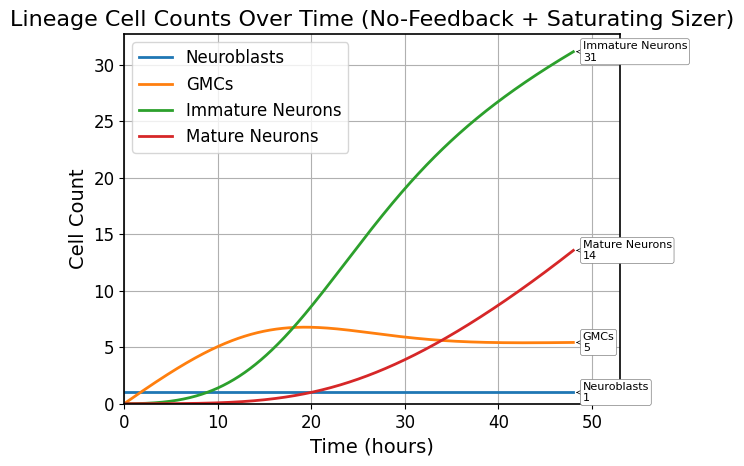

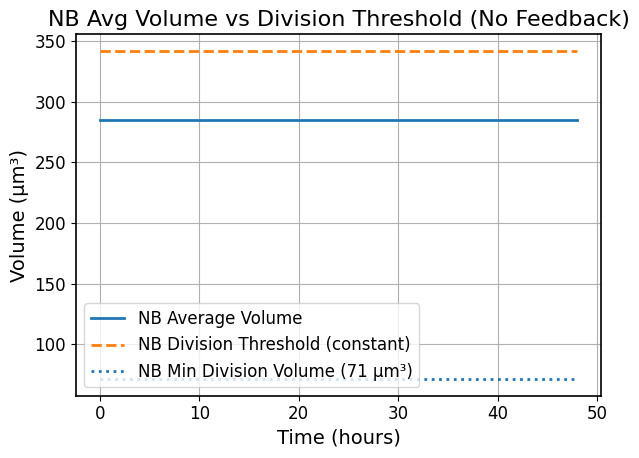

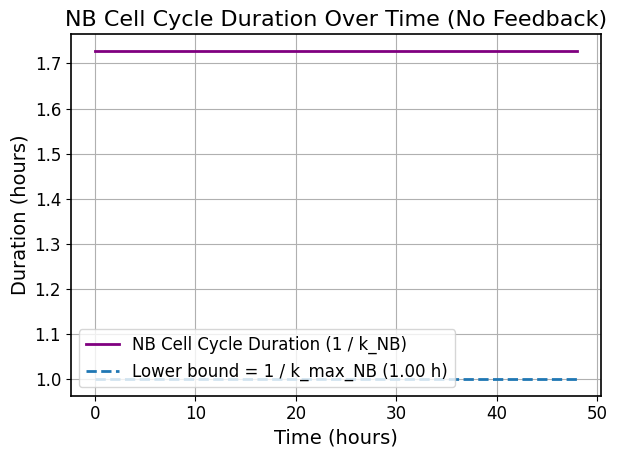

In [105]:
# --- WT params (NO FEEDBACK; saturating sizer division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)
V0 = nb_vol                                 # target steady NB avg volume

# Division kinetics (no feedback on parameters)
k_max_NB = 1                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 3                                # Exponent in the saturating sizer

# Thresholds (constants in this model)
V_thresh_NB  = 1.2 * nb_vol                 # NB threshold (constant)
V_thresh_GMC = (nb_vol * 1.2 * 0.2) * 2     # GMC threshold (constant)

# Floors
V_floor_NB  = 0.25 * nb_vol
V_floor_GMC = 0.25 * (nb_vol * 1.2 * 0.2)

# Growth rates (no feedback)
# Choose g_NB to keep NB avg volume constant at V0:
# g_NB = 0.2 * (1 - sym_frac) * k_NB(V0) * V0, where k_NB(V0) is the satpow hazard at V0
sym_frac = 0.0
core_V0  = min(1.0, (V0 / V_thresh_NB)**n)
k_at_V0  = k_max_NB * core_V0
g_NB     = 0.2 * (1.0 - sym_frac) * k_at_V0 * V0     # <-- exact balance => no drift

# GMC growth as before
g_GMC = (nb_vol * 1.2 * 0.2) / 9

k_Neuron = 1.0 / 48.0

# --- Parameter order for neuroblast_model_no_feedback_satpow ---
# (g_NB, g_GMC, k_Neuron, sym_frac,
#  V_thresh_NB, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_floor_GMC)
params_nf = [
    g_NB, g_GMC, k_Neuron, sym_frac,
    V_thresh_NB, V_thresh_GMC,
    k_max_NB, k_max_GMC, n,
    V_floor_NB, V_floor_GMC
]

# --- Initial conditions ---
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve (no-feedback model) ---
sol_nf = solve_ivp(
    neuroblast_model_no_feedback_satpow,
    t_span, y0, t_eval=t_eval, args=(params_nf,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_nf.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_nf.t, y, label=label)

ax.set_xlim(0, sol_nf.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_nf.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (No-Feedback + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs (constant) threshold (+ floor) ==========
Vavg_NB = np.divide(sol_nf.y[1], sol_nf.y[0],
                    out=np.zeros_like(sol_nf.y[1]),
                    where=sol_nf.y[0] > 0)

Vthresh_NB_t = np.full_like(Vavg_NB, V_thresh_NB)  # constant threshold

fig, ax = plt.subplots()
ax.plot(sol_nf.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_nf.t, Vthresh_NB_t, '--', label="NB Division Threshold (constant)")
ax.hlines(V_floor_NB, sol_nf.t[0], sol_nf.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume vs Division Threshold (No Feedback)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.minimum(1.0, np.where(V_thresh_NB > 0,
                                    (Vavg_NB / V_thresh_NB)**n, 0.0))
    k_NB_series = np.where(Vavg_NB >= V_floor_NB, k_max_NB * core, 0.0)

ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_nf.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_nf.t[0], sol_nf.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (No Feedback)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

mudmut Simulation

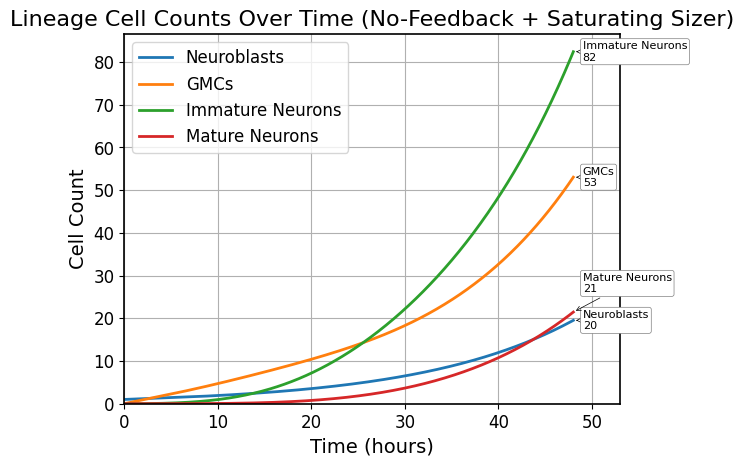

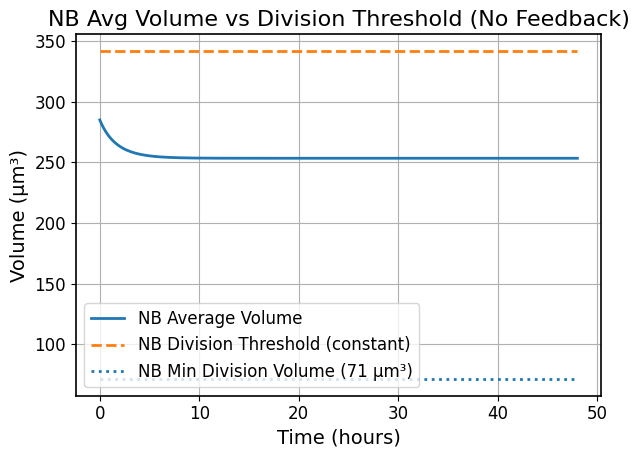

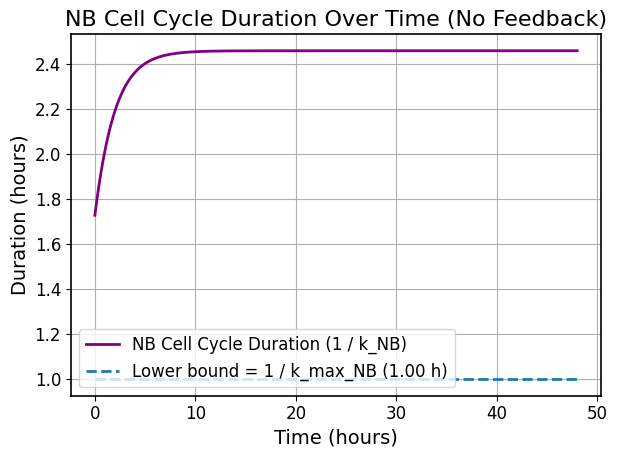

In [106]:
# --- mudmut params (NO FEEDBACK; saturating sizer division) ---
sym_frac = 0.15

# --- Parameter order for neuroblast_model_no_feedback_satpow ---
# (g_NB, g_GMC, k_Neuron, sym_frac,
#  V_thresh_NB, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_floor_GMC)
params_nf = [
    g_NB, g_GMC, k_Neuron, sym_frac,
    V_thresh_NB, V_thresh_GMC,
    k_max_NB, k_max_GMC, n,
    V_floor_NB, V_floor_GMC
]

# --- Initial conditions ---
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve (no-feedback model) ---
sol_nf = solve_ivp(
    neuroblast_model_no_feedback_satpow,
    t_span, y0, t_eval=t_eval, args=(params_nf,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_nf.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_nf.t, y, label=label)

ax.set_xlim(0, sol_nf.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_nf.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (No-Feedback + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs (constant) threshold (+ floor) ==========
Vavg_NB = np.divide(sol_nf.y[1], sol_nf.y[0],
                    out=np.zeros_like(sol_nf.y[1]),
                    where=sol_nf.y[0] > 0)

Vthresh_NB_t = np.full_like(Vavg_NB, V_thresh_NB)  # constant threshold

fig, ax = plt.subplots()
ax.plot(sol_nf.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_nf.t, Vthresh_NB_t, '--', label="NB Division Threshold (constant)")
ax.hlines(V_floor_NB, sol_nf.t[0], sol_nf.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume vs Division Threshold (No Feedback)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.minimum(1.0, np.where(V_thresh_NB > 0,
                                    (Vavg_NB / V_thresh_NB)**n, 0.0))
    k_NB_series = np.where(Vavg_NB >= V_floor_NB, k_max_NB * core, 0.0)

ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_nf.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_nf.t[0], sol_nf.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (No Feedback)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

nanobody

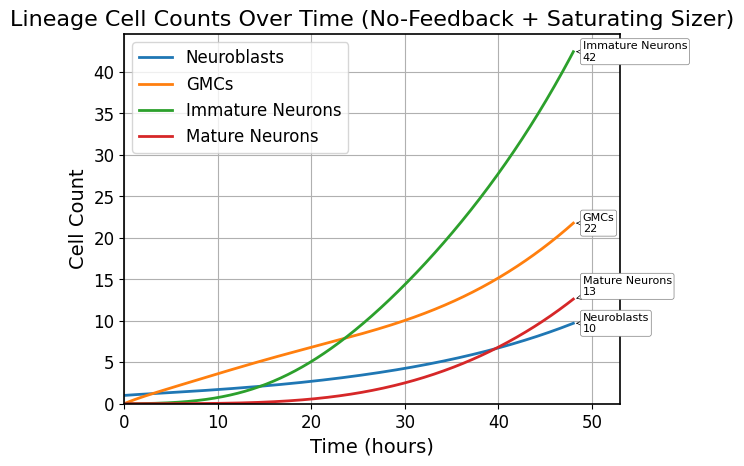

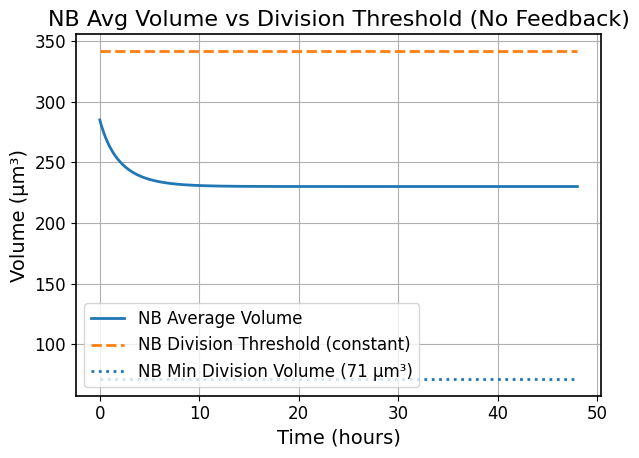

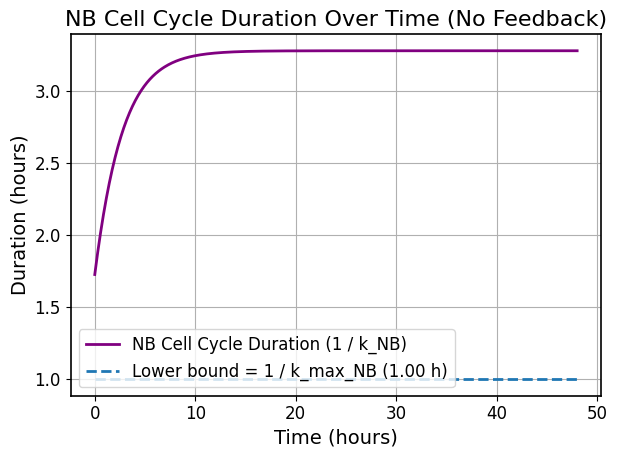

In [107]:
g_NB_WT     = 0.2 * (1.0 - sym_frac) * k_at_V0 * V0     # <-- exact balance => no drift
g_NB = .8 * g_NB_WT

# --- Parameter order for neuroblast_model_no_feedback_satpow ---
# (g_NB, g_GMC, k_Neuron, sym_frac,
#  V_thresh_NB, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_floor_GMC)
params_nf = [
    g_NB, g_GMC, k_Neuron, sym_frac,
    V_thresh_NB, V_thresh_GMC,
    k_max_NB, k_max_GMC, n,
    V_floor_NB, V_floor_GMC
]

# --- Initial conditions ---
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve (no-feedback model) ---
sol_nf = solve_ivp(
    neuroblast_model_no_feedback_satpow,
    t_span, y0, t_eval=t_eval, args=(params_nf,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_nf.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_nf.t, y, label=label)

ax.set_xlim(0, sol_nf.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_nf.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (No-Feedback + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs (constant) threshold (+ floor) ==========
Vavg_NB = np.divide(sol_nf.y[1], sol_nf.y[0],
                    out=np.zeros_like(sol_nf.y[1]),
                    where=sol_nf.y[0] > 0)

Vthresh_NB_t = np.full_like(Vavg_NB, V_thresh_NB)  # constant threshold

fig, ax = plt.subplots()
ax.plot(sol_nf.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_nf.t, Vthresh_NB_t, '--', label="NB Division Threshold (constant)")
ax.hlines(V_floor_NB, sol_nf.t[0], sol_nf.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume vs Division Threshold (No Feedback)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.minimum(1.0, np.where(V_thresh_NB > 0,
                                    (Vavg_NB / V_thresh_NB)**n, 0.0))
    k_NB_series = np.where(Vavg_NB >= V_floor_NB, k_max_NB * core, 0.0)

ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_nf.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_nf.t[0], sol_nf.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (No Feedback)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. Growth rate sensitivity to NB volume constrains mutant proliferation

**Hypothesis**
Since experimental observations suggest that NBs produced by symmetric divisions are smaller and grow more slowly than WT NBs, we hypothesized that regulating NB growth as a function of average NB volume would be sufficient to constrain mutant lineages.

**Methods**
Building on the volume-dependent division model (section 3), we scaled NB growth rate to the ratio of average NB volume to a reference volume (the WT division volume), raised to an exponent $\alpha_{\text{growth}}$:

$g_{NB,\text{eff}} = g_{NB,\text{base}} \left(\tfrac{\bar{V}{NB}}{V{\text{ref}}}\right)^{\alpha_{\text{growth}}}$.

WT parameters were calibrated to reproduce experimental dynamics. Mutants were simulated with 15% symmetric divisions (mudmut) or 15% symmetric divisions plus 80% WT growth rate (nanobody).

Results
Mutants produced fewer cells than WT when $\alpha_{\text{growth}} \geq 3$. Both mutants exhibited NB volumes collapsing toward the minimum floor volume, pausing their cell cycles for extended periods.

Conclusions
Volume-sensitive NB growth can explain why mutants produce fewer cells. However, the model assumes all NBs regrow to a fixed division threshold, whereas experimental evidence indicates that smaller mutant NBs divide at reduced thresholds. This points toward models where both growth rate and threshold scale with NB volume.

In [127]:
def neuroblast_model_vol_scaled_growth_only(t, y, params):
    """
    NB: growth rate scales with current NB size, but division threshold is constant.
        g_NB_eff = g_NB_base * (Vavg_NB / V_ref)^alpha_growth
        V_thresh_eff = V_thresh_base (constant)

    Division rates use a saturating power law:
        k_eff = k_max * min(1, (Vbar / V_thresh)^n)

    NB has a minimum division volume (V_floor_NB).
    GMCs: no feedback on growth or division params; optional GMC floor V_floor_GMC.
    """
    (N_NB, V_NB,
     N_GMC, V_GMC,
     N_ImNeuron, V_ImNeuron,
     N_MatNeuron, V_MatNeuron) = y

    (g_NB_base, g_GMC,
     k_Neuron,
     sym_frac,
     V_thresh_base,        # NB threshold (constant)
     V_thresh_GMC,         # GMC threshold (constant)
     k_max_NB, k_max_GMC,
     n,
     V_floor_NB,
     V_ref,
     alpha_growth,
     V_floor_GMC) = params

    # Averages (guard zero)
    Vavg_NB       = V_NB / N_NB if N_NB > 0 else 0.0
    Vavg_GMC      = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_ImNeuron = V_ImNeuron / N_ImNeuron if N_ImNeuron > 0 else 0.0

    # NB scaling (growth only)
    ratio    = (Vavg_NB / V_ref) if V_ref > 0 else 1.0
    g_NB_eff = g_NB_base * (ratio ** alpha_growth)

    # Division threshold: constant
    V_thresh_eff = V_thresh_base

    # Helper: satpow sizer
    def satpow_rate(Vbar, Vthresh, kmax, n):
        if Vbar <= 0 or Vthresh <= 0:
            return 0.0
        r = (Vbar / Vthresh) ** n
        return kmax * (1.0 if r >= 1.0 else r)

    # NB division rate (apply NB floor)
    if N_NB > 0 and Vavg_NB >= V_floor_NB and V_thresh_eff > 0:
        k_NB = satpow_rate(Vavg_NB, V_thresh_eff, k_max_NB, n)
    else:
        k_NB = 0.0

    # GMC division rate (satpow, no feedback; apply optional GMC floor)
    if N_GMC > 0 and Vavg_GMC >= V_floor_GMC and V_thresh_GMC > 0:
        k_GMC = satpow_rate(Vavg_GMC, V_thresh_GMC, k_max_GMC, n)
    else:
        k_GMC = 0.0

    # Division fluxes
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # ODEs
    dN_NB = sym_divs
    dV_NB = g_NB_eff * N_NB - 0.2 * asym_divs * Vavg_NB

    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = g_GMC * N_GMC + 0.2 * asym_divs * Vavg_NB - k_GMC * N_GMC * Vavg_GMC

    dN_ImNeuron = 2.0 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
    dV_ImNeuron = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_ImNeuron * Vavg_ImNeuron

    dN_MatNeuron = k_Neuron * N_ImNeuron
    dV_MatNeuron = k_Neuron * N_ImNeuron * Vavg_ImNeuron

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_ImNeuron, dV_ImNeuron,
        dN_MatNeuron, dV_MatNeuron
    ]

wt simulation

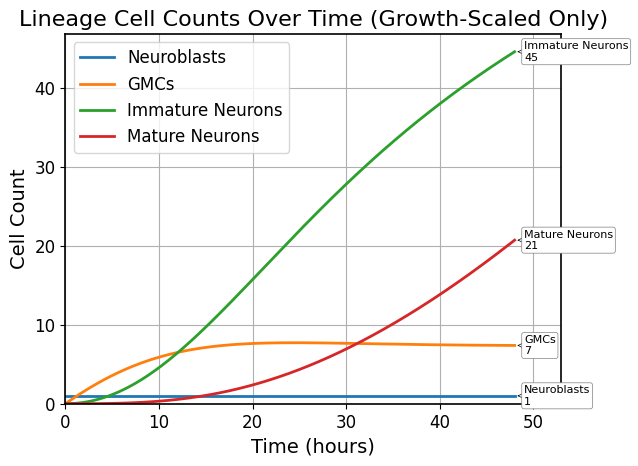

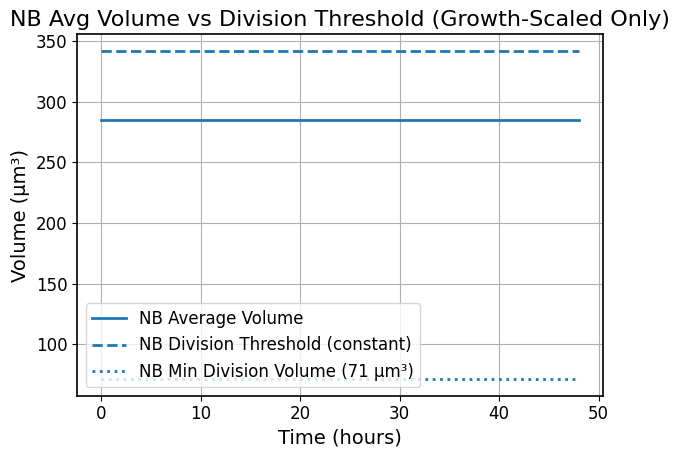

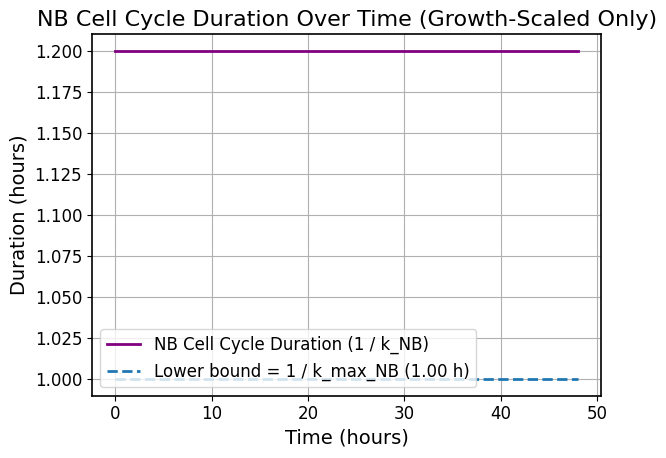

In [128]:
# --- WT params (GROWTH-SCALED ONLY; threshold constant; saturating sizer division) ---
nb_vol = 285
V0 = nb_vol  # target steady NB avg volume


# Division kinetics (no feedback on thresholds)
k_max_NB = 1 # divisions/hour
k_max_GMC = 1.0 / 8.0         # Max GMC division rate (divisions/hr)
n         = 1                 # Saturating sizer exponent (steeper than n=2)

# Thresholds (constants)
V_thresh_NB  = 1.2 * nb_vol
V_thresh_GMC = (nb_vol * 1.2 * 0.2) * 2

# Floors
V_floor_NB  = 0.25 * nb_vol
V_floor_GMC = 0.25 * (nb_vol * 1.2 * 0.2)

# Growth scaling (NB only)
V_ref        = V0              # reference NB volume for scaling
alpha_growth = 3               # growth sensitivity to NB size (only growth scales)

# Choose g_NB_base to keep NB avg volume constant at V0.
# Balance condition at V0:
#   g_NB_eff(V0) = 0.2 * (1 - sym_frac) * k_NB(V0) * V0
# with g_NB_eff(V0) = g_NB_base * (V0 / V_ref)^alpha_growth
sym_frac = 0.0
core_V0  = min(1.0, (V0 / V_thresh_NB)**n)         # satpow core at V0
k_at_V0  = k_max_NB * core_V0                      # NB division hazard at V0
g_NB_eff_at_V0 = 0.2 * (1.0 - sym_frac) * k_at_V0 * V0
# If V_ref = V0, the scaling factor at V0 is 1, so g_NB_base = g_NB_eff_at_V0
g_NB_base = g_NB_eff_at_V0

# GMC growth as before (no feedback)
g_GMC = (nb_vol * 1.2 * 0.2) / 9
k_Neuron = 1.0 / 48.0

# --- Parameter pack for growth-scaled-only model ---
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, V_floor_GMC)
params_gonly = [
    g_NB_base, g_GMC, k_Neuron, sym_frac,
    V_thresh_NB, V_thresh_GMC,
    k_max_NB, k_max_GMC, n,
    V_floor_NB, V_ref, alpha_growth, V_floor_GMC
]

# --- Initial conditions ---
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_gonly = solve_ivp(
    neuroblast_model_vol_scaled_growth_only,
    t_span, y0, t_eval=t_eval, args=(params_gonly,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_gonly.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_gonly.t, y, label=label)

ax.set_xlim(0, sol_gonly.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_gonly.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_gonly.y[1], sol_gonly.y[0],
                    out=np.zeros_like(sol_gonly.y[1]),
                    where=sol_gonly.y[0] > 0)

fig, ax = plt.subplots()
ax.plot(sol_gonly.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.hlines(V_thresh_NB, sol_gonly.t[0], sol_gonly.t[-1], linestyles="--", label="NB Division Threshold (constant)")
ax.hlines(V_floor_NB,  sol_gonly.t[0], sol_gonly.t[-1], linestyles=":",  label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume vs Division Threshold (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.minimum(1.0, (Vavg_NB / V_thresh_NB)**n)
    k_NB_series = np.where(Vavg_NB >= V_floor_NB, k_max_NB * core, 0.0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_gonly.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_gonly.t[0], sol_gonly.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

mudmut simulation

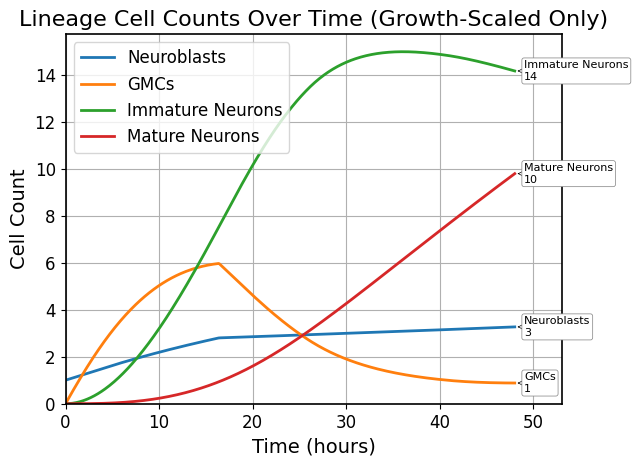

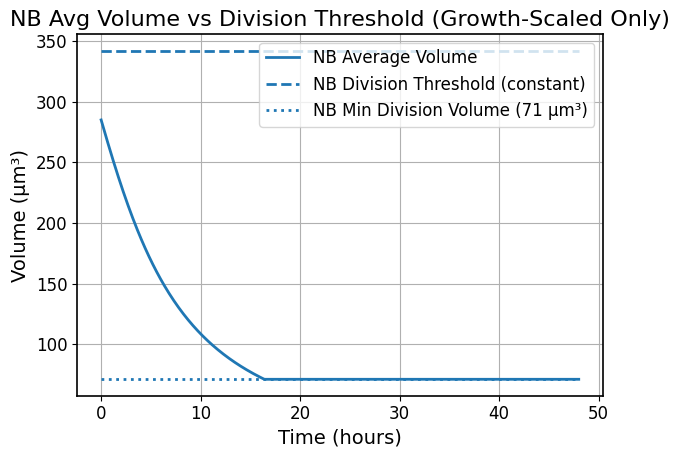

/var/folders/2c/ggmnjcgs6zv79p4w57qtvtr80000gn/T/ipykernel_45679/88034069.py:73: RuntimeWarning: divide by zero encountered in divide
  ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)


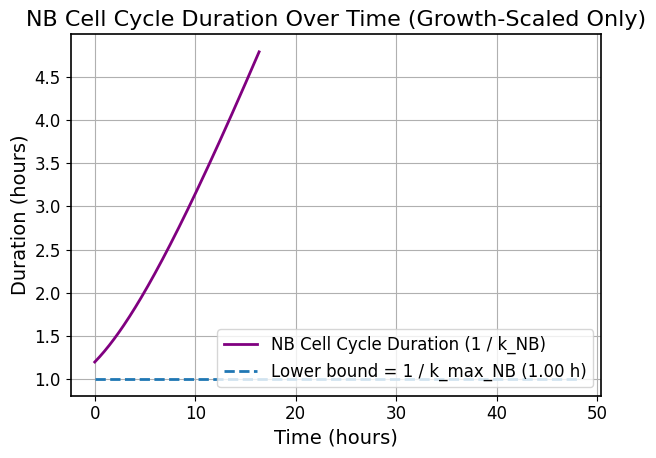

In [129]:
# --- mudmut params (GROWTH-SCALED ONLY; threshold constant; saturating sizer division) ---
sym_frac = 0.15

# --- Parameter pack for growth-scaled-only model ---
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, V_floor_GMC)
params_gonly = [
    g_NB_base, g_GMC, k_Neuron, sym_frac,
    V_thresh_NB, V_thresh_GMC,
    k_max_NB, k_max_GMC, n,
    V_floor_NB, V_ref, alpha_growth, V_floor_GMC
]

# --- Initial conditions ---
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_gonly = solve_ivp(
    neuroblast_model_vol_scaled_growth_only,
    t_span, y0, t_eval=t_eval, args=(params_gonly,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_gonly.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_gonly.t, y, label=label)

ax.set_xlim(0, sol_gonly.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_gonly.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_gonly.y[1], sol_gonly.y[0],
                    out=np.zeros_like(sol_gonly.y[1]),
                    where=sol_gonly.y[0] > 0)

fig, ax = plt.subplots()
ax.plot(sol_gonly.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.hlines(V_thresh_NB, sol_gonly.t[0], sol_gonly.t[-1], linestyles="--", label="NB Division Threshold (constant)")
ax.hlines(V_floor_NB,  sol_gonly.t[0], sol_gonly.t[-1], linestyles=":",  label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume vs Division Threshold (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.minimum(1.0, (Vavg_NB / V_thresh_NB)**n)
    k_NB_series = np.where(Vavg_NB >= V_floor_NB, k_max_NB * core, 0.0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_gonly.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_gonly.t[0], sol_gonly.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

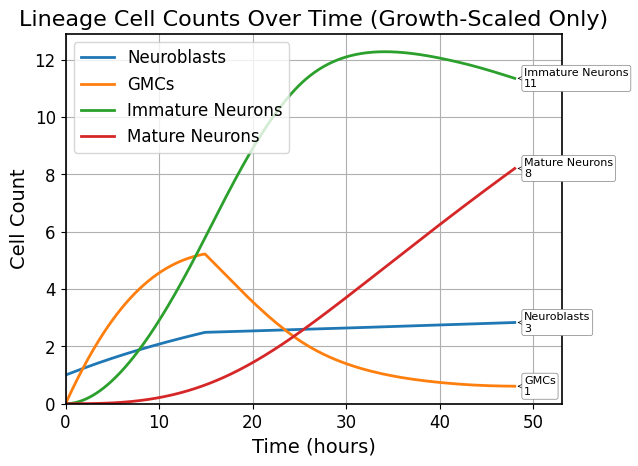

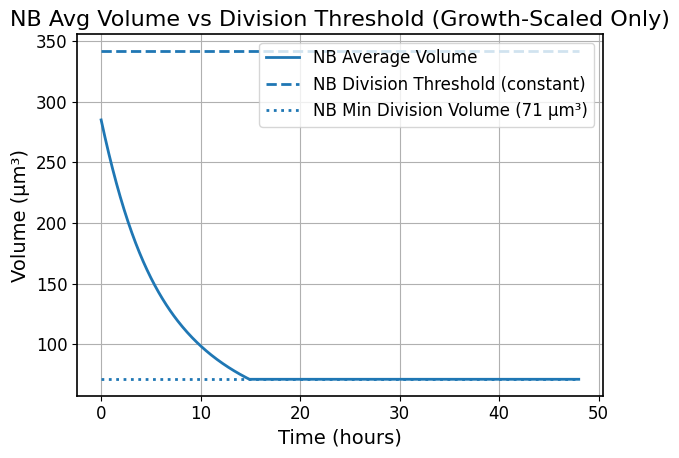

/var/folders/2c/ggmnjcgs6zv79p4w57qtvtr80000gn/T/ipykernel_45679/1119093635.py:75: RuntimeWarning: divide by zero encountered in divide
  ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)


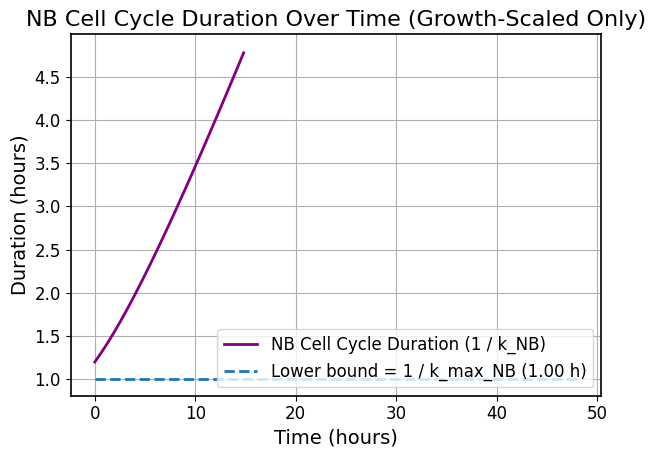

In [130]:
# --- nanobody params (GROWTH-SCALED ONLY; threshold constant; saturating sizer division) ---
sym_frac = 0.15
WT_g_NB_base = g_NB_base
g_NB_base = WT_g_NB_base * .8

# --- Parameter pack for growth-scaled-only model ---
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, V_floor_GMC)
params_gonly = [
    g_NB_base, g_GMC, k_Neuron, sym_frac,
    V_thresh_NB, V_thresh_GMC,
    k_max_NB, k_max_GMC, n,
    V_floor_NB, V_ref, alpha_growth, V_floor_GMC
]

# --- Initial conditions ---
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_gonly = solve_ivp(
    neuroblast_model_vol_scaled_growth_only,
    t_span, y0, t_eval=t_eval, args=(params_gonly,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_gonly.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_gonly.t, y, label=label)

ax.set_xlim(0, sol_gonly.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_gonly.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_gonly.y[1], sol_gonly.y[0],
                    out=np.zeros_like(sol_gonly.y[1]),
                    where=sol_gonly.y[0] > 0)

fig, ax = plt.subplots()
ax.plot(sol_gonly.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.hlines(V_thresh_NB, sol_gonly.t[0], sol_gonly.t[-1], linestyles="--", label="NB Division Threshold (constant)")
ax.hlines(V_floor_NB,  sol_gonly.t[0], sol_gonly.t[-1], linestyles=":",  label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume vs Division Threshold (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
with np.errstate(divide='ignore', invalid='ignore'):
    core = np.minimum(1.0, (Vavg_NB / V_thresh_NB)**n)
    k_NB_series = np.where(Vavg_NB >= V_floor_NB, k_max_NB * core, 0.0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_gonly.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_gonly.t[0], sol_gonly.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Growth-Scaled Only)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

---

## 5. Joint regulation of NB growth and division threshold by volume is sufficient to constrain mutant colonies

**Hypothesis**
In section 4, we showed that volume-sensitive NB growth can reduce mutant proliferation, but because the division threshold was fixed, smaller NBs were doubly penalized: they had more volume to add and did so more slowly than larger cells. Biologically, however, smaller NBs may also divide at proportionally smaller sizes as has been observed in mudmut NBs, partially offsetting this disadvantage. We therefore hypothesized that if both NB growth rate and division threshold scale with NB volume, the opposing effects could balance, allowing WT colonies to still outgrow mutants.

**Methods**
We extended the model from section 4 by also scaling the division threshold volume:

$V_{\text{thresh,eff}} = V_{\text{thresh,base}} \left(\tfrac{\bar{V}{NB}}{V{\text{ref}}}\right)^{\alpha_{\text{thresh}}}$.

Mutant conditions were defined as in section 4.

**Results**
Mutant lineages again produced fewer cells than WT when $\alpha_{\text{growth}} \geq 3$. Setting $\alpha_{\text{thresh}}$ low prevented NBs from collapsing to their minimum volume and increased mutant cell counts relative to section 4. High $\alpha_{\text{thresh}}$ caused mutant NBs to crash to their minimum volume and fail to recover, halting proliferation entirely.

**Conclusions**
This model shows that volume-based regulation of both NB growth and division threshold is sufficient to reproduce experimental trends. The balance between $\alpha_{\text{growth}}$ and $\alpha_{\text{thresh}}$ controls whether simulated mutant colonies grow slowly or arrest completely.

In [148]:
def neuroblast_model_vol_scaled_growth_and_threshold_satpow(t, y, params):
    """
    NB: growth and NB division threshold scale with current NB size.
        g_NB_eff = g_NB_base * (Vavg_NB / V_ref)^alpha_growth
        V_thresh_eff = V_thresh_base * (Vavg_NB / V_ref)^alpha_thresh
    Division rates use a saturating power law:
        k_eff = k_max * min(1, (Vbar / V_thresh)^n)

    NB has an NB volume floor (V_floor_NB).
    GMCs: no feedback on growth or division params; optional GMC floor V_floor_GMC.
    """
    (N_NB, V_NB,
     N_GMC, V_GMC,
     N_ImNeuron, V_ImNeuron,
     N_MatNeuron, V_MatNeuron) = y

    (g_NB_base, g_GMC,
     k_Neuron,
     sym_frac,
     V_thresh_base,        # NB threshold base (scaled by NB size)
     V_thresh_GMC,         # GMC threshold (constant)
     k_max_NB, k_max_GMC,
     n,
     V_floor_NB,
     V_ref,
     alpha_growth, alpha_thresh,
     V_floor_GMC) = params  # <-- NEW: optional GMC floor (set 0.0 to disable)

    # Averages (guard zero)
    Vavg_NB       = V_NB / N_NB if N_NB > 0 else 0.0
    Vavg_GMC      = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_ImNeuron = V_ImNeuron / N_ImNeuron if N_ImNeuron > 0 else 0.0

    # NB scaling
    ratio        = (Vavg_NB / V_ref) if V_ref > 0 else 1.0
    g_NB_eff     = g_NB_base * (ratio ** alpha_growth)
    V_thresh_eff = V_thresh_base * (ratio ** alpha_thresh)

    # Helper: satpow sizer
    def satpow_rate(Vbar, Vthresh, kmax, n):
        if Vbar <= 0 or Vthresh <= 0:
            return 0.0
        r = (Vbar / Vthresh) ** n
        return kmax * (1.0 if r >= 1.0 else r)

    # NB division rate (apply NB floor)
    if N_NB > 0 and Vavg_NB >= V_floor_NB and V_thresh_eff > 0:
        k_NB = satpow_rate(Vavg_NB, V_thresh_eff, k_max_NB, n)
    else:
        k_NB = 0.0

    # GMC division rate (satpow, no feedback; apply optional GMC floor)
    if N_GMC > 0 and Vavg_GMC >= V_floor_GMC and V_thresh_GMC > 0:
        k_GMC = satpow_rate(Vavg_GMC, V_thresh_GMC, k_max_GMC, n)
    else:
        k_GMC = 0.0

    # Division fluxes
    sym_divs  = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # ODEs
    dN_NB = sym_divs
    dV_NB = g_NB_eff * N_NB - 0.2 * asym_divs * Vavg_NB

    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = g_GMC * N_GMC + 0.2 * asym_divs * Vavg_NB - k_GMC * N_GMC * Vavg_GMC

    dN_ImNeuron = 2.0 * k_GMC * N_GMC - k_Neuron * N_ImNeuron
    dV_ImNeuron = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_ImNeuron * Vavg_ImNeuron

    dN_MatNeuron = k_Neuron * N_ImNeuron
    dV_MatNeuron = k_Neuron * N_ImNeuron * Vavg_ImNeuron

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_ImNeuron, dV_ImNeuron,
        dN_MatNeuron, dV_MatNeuron
    ]

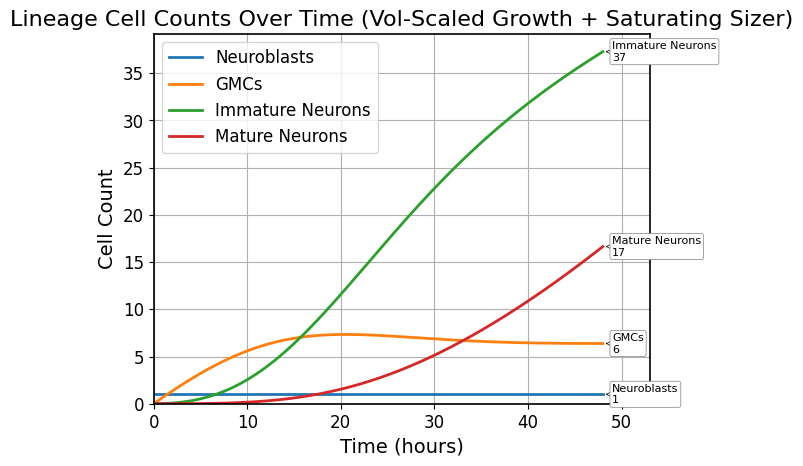

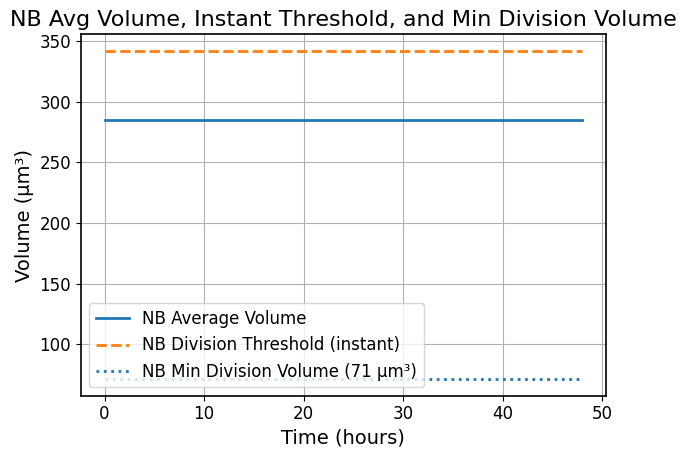

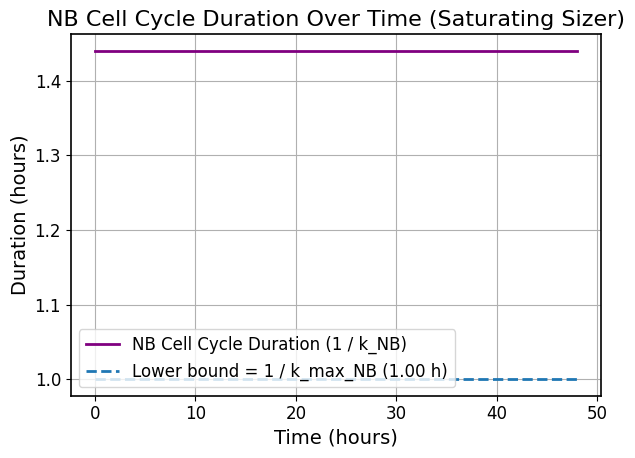

In [154]:
# --- WT params (volume-scaled growth + saturating sizer division) ---
nb_vol = 285                                # Initial neuroblast volume (µm³)

# Reference & thresholds
V_ref         = nb_vol                      # Reference volume for NB growth/threshold scaling
V_thresh_base = 1.2 * nb_vol                # Base NB threshold at V_ref

# Division kinetics
k_max_NB  = 1.0                             # Max NB division rate (divisions/hr)
k_max_GMC = 1.0 / 8.0                       # Max GMC division rate (divisions/hr)
n         = 2                               # Exponent in the saturating sizer

# Scaling exponents
alpha_thresh = .1
alpha_growth = 3

# Enforce zero net drift of NB volume in WTs:
# g_NB_base = 0.2 * k_NB_const * V_ref, with k_NB_const = k_max_NB * min(1, (V_ref / V_thresh_base)^n)
core        = min(1.0, (V_ref / V_thresh_base)**n)
k_NB_const  = k_max_NB * core
g_NB_base   = 0.2 * k_NB_const * V_ref      # <-- adjusted NB base growth rate

# Other rates/thresholds unchanged
g_GMC        = (nb_vol * 1.2 * 0.2) / 9     # GMC growth rate (volume/hr)
V_thresh_GMC = (nb_vol * 1.2 * 0.2) * 2     # GMC division threshold volume (µm³)

sym_frac     = 0.0                           # Fraction of NB divisions that are symmetric
k_Neuron     = 1.0 / 48.0                    # Immature neuron maturation rate (1/hr)
V_floor_NB   = .25*nb_vol                  # Min avg NB volume before division allowed
v_floor_GMC = .25*(nb_vol*1.2*.2)

# Parameter order for the saturating model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, alpha_thresh)
params_vol_scaled_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    V_thresh_base, V_thresh_GMC,
    k_max_NB, k_max_GMC,
    n,
    V_floor_NB, V_ref,
    alpha_growth, alpha_thresh, v_floor_GMC
]

# Initial conditions
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_vol_scaled = solve_ivp(
    neuroblast_model_vol_scaled_growth_and_threshold_satpow,
    t_span, y0, t_eval=t_eval, args=(params_vol_scaled_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_vol_scaled.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_vol_scaled.t, y, label=label)

ax.set_xlim(0, sol_vol_scaled.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_vol_scaled.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Vol-Scaled Growth + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)

# Instantaneous threshold over time (scaled to NB avg volume):
Vthresh_NB_t = V_thresh_base * (np.divide(Vavg_NB, V_ref,
                                          out=np.ones_like(Vavg_NB),
                                          where=V_ref > 0) ** alpha_thresh)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_vol_scaled.t, Vthresh_NB_t, '--', label="NB Division Threshold (instant)")
ax.hlines(V_floor_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume, Instant Threshold, and Min Division Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
# Recompute Vavg and ratio
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)
ratio = np.divide(Vavg_NB, V_ref, out=np.ones_like(Vavg_NB), where=V_ref > 0)

# Instant effective threshold series for NBs
V_thresh_eff_series = V_thresh_base * (ratio ** alpha_thresh)

# Instantaneous NB division rate using saturating sizer:
with np.errstate(divide='ignore', invalid='ignore'):
    # core saturating term: min(1, (Vavg_NB / V_thresh_eff)^n)
    core = np.where(V_thresh_eff_series > 0,
                    (Vavg_NB / V_thresh_eff_series) ** n,
                    0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = np.where(
        Vavg_NB >= V_floor_NB,
        k_max_NB * core,
        0.0
    )

# Cell-cycle duration = 1 / k_NB (NaN when k_NB = 0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Saturating Sizer)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

mudmut simulation

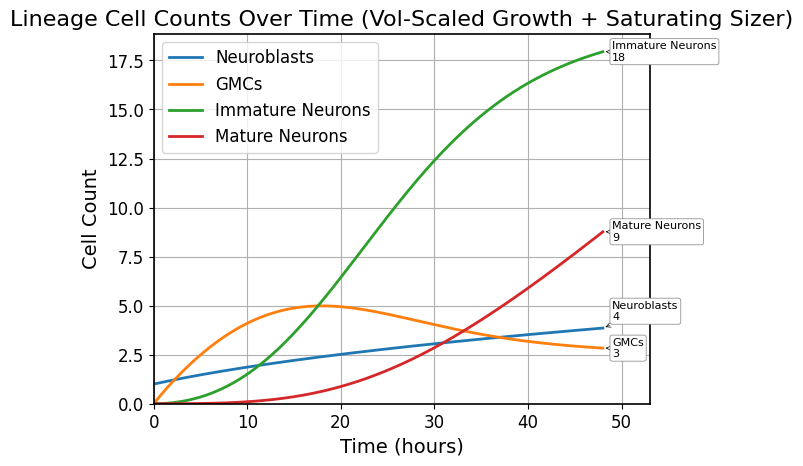

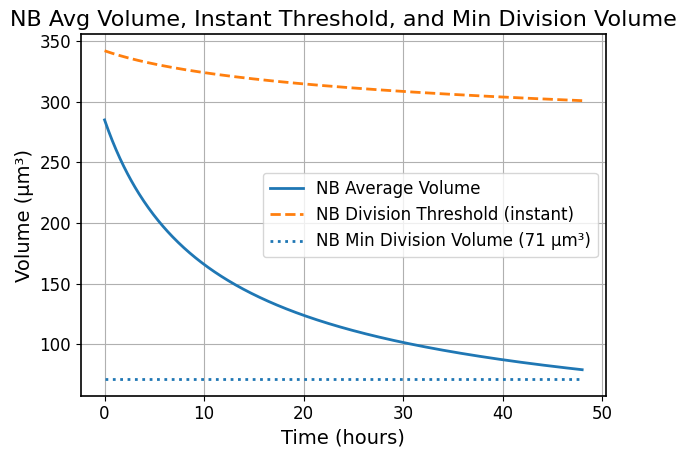

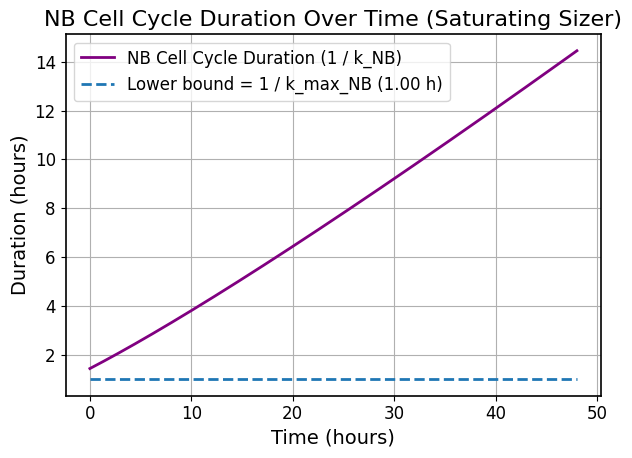

In [155]:
# --- mudmut params (volume-scaled growth + saturating sizer division) ---
sym_frac     = 0.15                           # Fraction of NB divisions that are symmetric


# Parameter order for the saturating model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, alpha_thresh)
params_vol_scaled_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    V_thresh_base, V_thresh_GMC,
    k_max_NB, k_max_GMC,
    n,
    V_floor_NB, V_ref,
    alpha_growth, alpha_thresh, v_floor_GMC
]

# Initial conditions
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_vol_scaled = solve_ivp(
    neuroblast_model_vol_scaled_growth_and_threshold_satpow,
    t_span, y0, t_eval=t_eval, args=(params_vol_scaled_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_vol_scaled.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_vol_scaled.t, y, label=label)

ax.set_xlim(0, sol_vol_scaled.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_vol_scaled.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Vol-Scaled Growth + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)

# Instantaneous threshold over time (scaled to NB avg volume):
Vthresh_NB_t = V_thresh_base * (np.divide(Vavg_NB, V_ref,
                                          out=np.ones_like(Vavg_NB),
                                          where=V_ref > 0) ** alpha_thresh)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_vol_scaled.t, Vthresh_NB_t, '--', label="NB Division Threshold (instant)")
ax.hlines(V_floor_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume, Instant Threshold, and Min Division Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
# Recompute Vavg and ratio
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)
ratio = np.divide(Vavg_NB, V_ref, out=np.ones_like(Vavg_NB), where=V_ref > 0)

# Instant effective threshold series for NBs
V_thresh_eff_series = V_thresh_base * (ratio ** alpha_thresh)

# Instantaneous NB division rate using saturating sizer:
with np.errstate(divide='ignore', invalid='ignore'):
    # core saturating term: min(1, (Vavg_NB / V_thresh_eff)^n)
    core = np.where(V_thresh_eff_series > 0,
                    (Vavg_NB / V_thresh_eff_series) ** n,
                    0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = np.where(
        Vavg_NB >= V_floor_NB,
        k_max_NB * core,
        0.0
    )

# Cell-cycle duration = 1 / k_NB (NaN when k_NB = 0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Saturating Sizer)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

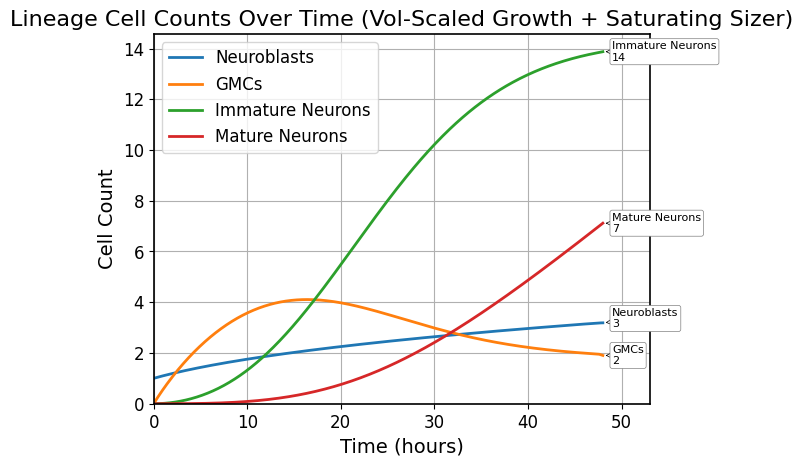

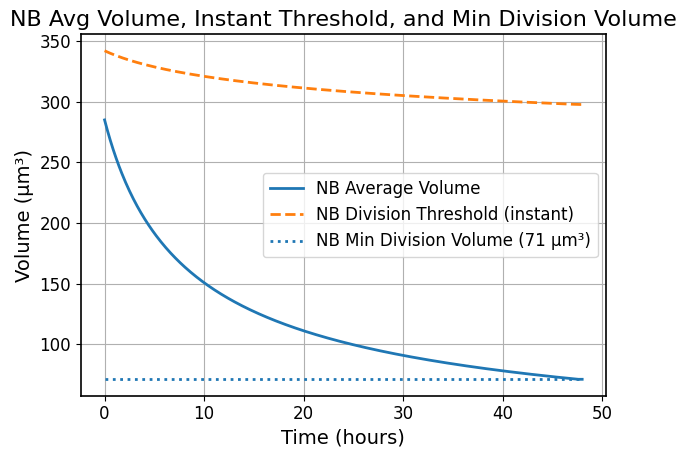

/var/folders/2c/ggmnjcgs6zv79p4w57qtvtr80000gn/T/ipykernel_45679/370920212.py:105: RuntimeWarning: divide by zero encountered in divide
  ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)


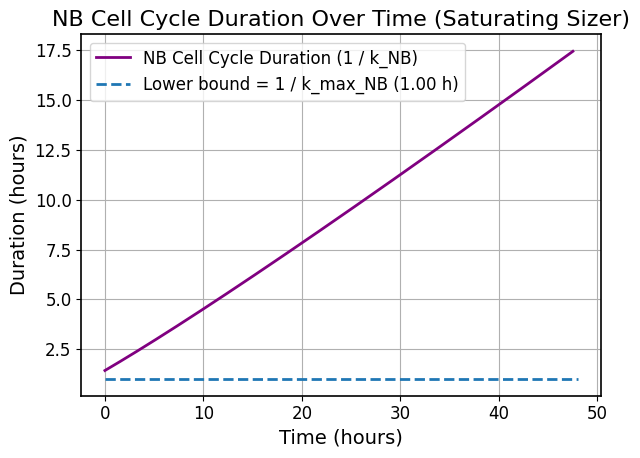

In [151]:
# --- mudmut params (volume-scaled growth + saturating sizer division) ---
sym_frac     = 0.15                           # Fraction of NB divisions that are symmetric
WT_g_NB_base = g_NB_base
g_NB_base = WT_g_NB_base*.8

# Parameter order for the saturating model:
# (g_NB_base, g_GMC, k_Neuron, sym_frac,
#  V_thresh_base, V_thresh_GMC,
#  k_max_NB, k_max_GMC, n,
#  V_floor_NB, V_ref, alpha_growth, alpha_thresh)
params_vol_scaled_sat = [
    g_NB_base, g_GMC,
    k_Neuron,
    sym_frac,
    V_thresh_base, V_thresh_GMC,
    k_max_NB, k_max_GMC,
    n,
    V_floor_NB, V_ref,
    alpha_growth, alpha_thresh, v_floor_GMC
]

# Initial conditions
# [N_NB, V_NB, N_GMC, V_GMC, N_ImNeuron, V_ImNeuron, N_MatNeuron, V_MatNeuron]
y0 = [1, nb_vol, 0, 0, 0, 0, 0, 0]

t_span = [0, 48]
t_eval = np.linspace(*t_span, 500)

# --- Solve ---
sol_vol_scaled = solve_ivp(
    neuroblast_model_vol_scaled_growth_and_threshold_satpow,
    t_span, y0, t_eval=t_eval, args=(params_vol_scaled_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_vol_scaled.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_vol_scaled.t, y, label=label)

ax.set_xlim(0, sol_vol_scaled.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_vol_scaled.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("Lineage Cell Counts Over Time (Vol-Scaled Growth + Saturating Sizer)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: NB avg volume vs threshold (+ floor) ==========
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)

# Instantaneous threshold over time (scaled to NB avg volume):
Vthresh_NB_t = V_thresh_base * (np.divide(Vavg_NB, V_ref,
                                          out=np.ones_like(Vavg_NB),
                                          where=V_ref > 0) ** alpha_thresh)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, Vavg_NB, label="NB Average Volume", linewidth=2)
ax.plot(sol_vol_scaled.t, Vthresh_NB_t, '--', label="NB Division Threshold (instant)")
ax.hlines(V_floor_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles=":", label=f"NB Min Division Volume ({V_floor_NB:.0f} µm³)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Volume (µm³)")
ax.set_title("NB Avg Volume, Instant Threshold, and Min Division Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB cell-cycle duration (1 / k_NB) ==========
# Recompute Vavg and ratio
Vavg_NB = np.divide(sol_vol_scaled.y[1], sol_vol_scaled.y[0],
                    out=np.zeros_like(sol_vol_scaled.y[1]),
                    where=sol_vol_scaled.y[0] > 0)
ratio = np.divide(Vavg_NB, V_ref, out=np.ones_like(Vavg_NB), where=V_ref > 0)

# Instant effective threshold series for NBs
V_thresh_eff_series = V_thresh_base * (ratio ** alpha_thresh)

# Instantaneous NB division rate using saturating sizer:
with np.errstate(divide='ignore', invalid='ignore'):
    # core saturating term: min(1, (Vavg_NB / V_thresh_eff)^n)
    core = np.where(V_thresh_eff_series > 0,
                    (Vavg_NB / V_thresh_eff_series) ** n,
                    0.0)
    core = np.minimum(core, 1.0)
    k_NB_series = np.where(
        Vavg_NB >= V_floor_NB,
        k_max_NB * core,
        0.0
    )

# Cell-cycle duration = 1 / k_NB (NaN when k_NB = 0)
ccd_hazard = np.where(k_NB_series > 0, 1.0 / k_NB_series, np.nan)

fig, ax = plt.subplots()
ax.plot(sol_vol_scaled.t, ccd_hazard, color="purple", label="NB Cell Cycle Duration (1 / k_NB)")
ax.hlines(1.0 / k_max_NB, sol_vol_scaled.t[0], sol_vol_scaled.t[-1],
          linestyles="--", label=f"Lower bound = 1 / k_max_NB ({1.0/k_max_NB:.2f} h)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_title("NB Cell Cycle Duration Over Time (Saturating Sizer)")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. Birth-volume sensitive NB growth and division is sufficient to drive differences between mutant and WT NB colonies.

**Hypothesis**: Sizer models (sections 3–5) assume that cells divide when they reach a threshold volume. Alternatively, division dynamics may be dictated by the NB’s initial (birth) volume, consistent with an “adder” regime. We hypothesized that regulating growth and division based on birth volume would also constrain mutant colonies.

**Method**: We modified the model from section 5 to include bookkeeping of NB birth volumes. Both growth rate and division rate were scaled to the ratio of average NB birth volume to a WT reference, raised to exponents \alpha_{\text{growth}} and \alpha_{\text{division}}, respectively.

**Result**: Mutants produced fewer cells than WT when both exponents were set to 3.

**Conclusions**: Even in a birth-volume–dependent regime, regulation of NB growth and division is sufficient to explain why mutant colonies produce fewer cells. This robustness suggests that volume-based regulation is a plausible biological mechanism constraining mutant lineages.

In [156]:
def neuroblast_model_volume_powerlaw_birth_diffs(t, y, params):
    """
    Neuroblast model with saturating power-law division dynamics
    and birth-volume bookkeeping for NBs and GMCs.

    State vector:
        y = [N_NB, V_NB, N_GMC, V_GMC, N_Im, V_Im, N_Mat, V_Mat, S_NB, S_GMC]
            N_*  : cell counts
            V_*  : total volumes
            S_*  : sum of birth volumes (NB or GMC)

    Parameters:
        g_NB_base    : base NB growth rate (volume/hour)
        g_GMC        : GMC growth rate (volume/hour)
        k_Neuron     : maturation rate (1/hour)
        sym_frac     : fraction of NB divisions that are symmetric [0..1]
        k_max_NB     : max NB division rate (1/hour)
        k_max_GMC    : max GMC division rate (1/hour)
        n            : exponent for saturating power-law division dynamics
        V_ref_NB     : reference NB birth volume
        V_ref_GMC    : reference NB birth volume
        alpha_birth_growth  : NB growth scaling exponent based on birth volume
        alpha_birth_division  : NB growth scaling exponent based on birth volume
    """
    (N_NB, V_NB,
     N_GMC, V_GMC,
     N_Im,  V_Im,
     N_Mat, V_Mat,
     S_NB, S_GMC) = y

    (g_NB_base, g_GMC,
     k_Neuron,
     sym_frac,
     k_avg_NB, k_avg_GMC,
     alpha_birth_division,
     V_ref_NB, V_ref_GMC, alpha_birth_growth) = params

    # --- Averages ---
    Vavg_NB = V_NB / N_NB if N_NB > 0 else 0.0
    Vavg_GMC = V_GMC / N_GMC if N_GMC > 0 else 0.0
    Vavg_Im = V_Im / N_Im if N_Im > 0 else 0.0

    Bavg_NB = S_NB / N_NB if N_NB > 0 else 0.0
    Bavg_GMC = S_GMC / N_GMC if N_GMC > 0 else 0.0

    # --- NB growth scaling ---
    scale_birth = (Bavg_NB / V_ref_NB) ** alpha_birth_growth if V_ref_NB > 0 and Bavg_NB > 0 else (0.0 if alpha_birth_growth > 0 else 1.0)
    g_NB_eff = g_NB_base * scale_birth

    # --- Division rates ---
    k_NB = 0.0
    if N_NB > 0:
        core_NB = (Bavg_NB / V_ref_NB)**alpha_birth_division
        k_NB = core_NB * k_avg_NB

    k_GMC = 0.0
    if N_GMC > 0:
        core_GMC = (Bavg_GMC / V_ref_GMC)**alpha_birth_division
        k_GMC = core_GMC * k_avg_GMC

    # --- Division fluxes ---
    sym_divs = sym_frac * k_NB * N_NB
    asym_divs = (1.0 - sym_frac) * k_NB * N_NB

    # --- ODEs ---
    dN_NB = sym_divs
    dV_NB = (
        g_NB_eff * N_NB
        - k_NB * N_NB * Vavg_NB
        + sym_divs * Vavg_NB
        + asym_divs * 0.8 * Vavg_NB
    )
    dS_NB = (
        -k_NB * N_NB * Bavg_NB
        + sym_divs * Vavg_NB
        + asym_divs * (0.8 * Vavg_NB)
    )

    dN_GMC = asym_divs - k_GMC * N_GMC
    dV_GMC = (
        g_GMC * N_GMC
        + asym_divs * 0.2 * Vavg_NB
        - k_GMC * N_GMC * Vavg_GMC
    )
    dS_GMC = (
        -k_GMC * N_GMC * Bavg_GMC
        + asym_divs * 0.2 * Vavg_NB
    )

    dN_Im = 2.0 * k_GMC * N_GMC - k_Neuron * N_Im
    dV_Im = k_GMC * N_GMC * Vavg_GMC - k_Neuron * N_Im * Vavg_Im

    dN_Mat = k_Neuron * N_Im
    dV_Mat = k_Neuron * N_Im * Vavg_Im

    return [
        dN_NB, dV_NB,
        dN_GMC, dV_GMC,
        dN_Im,  dV_Im,
        dN_Mat, dV_Mat,
        dS_NB, dS_GMC
    ]

WT Simulation

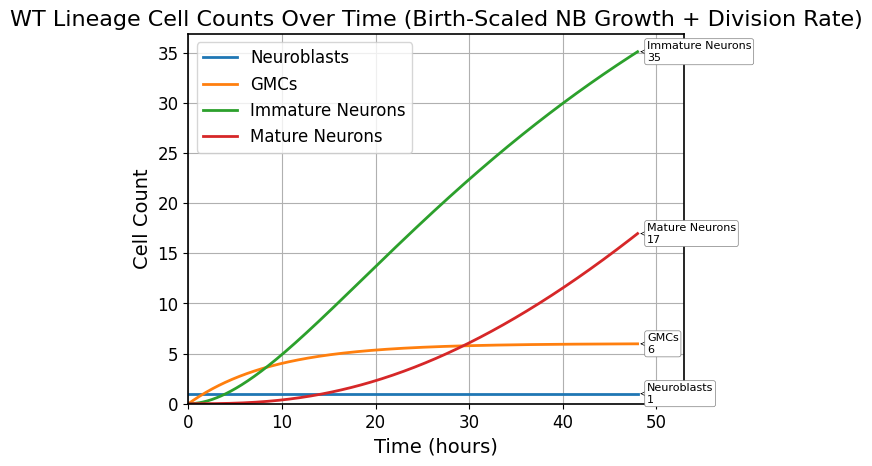

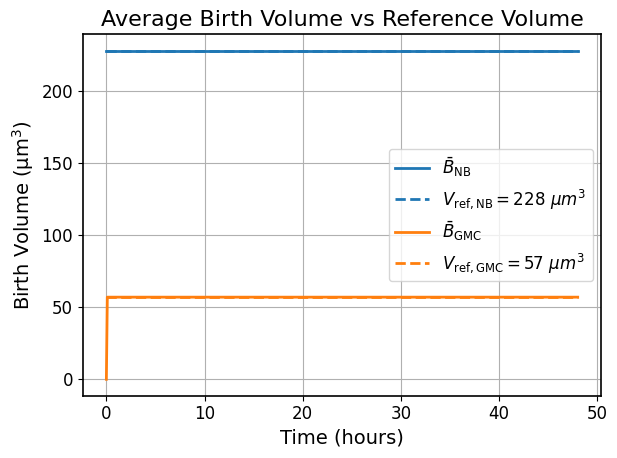

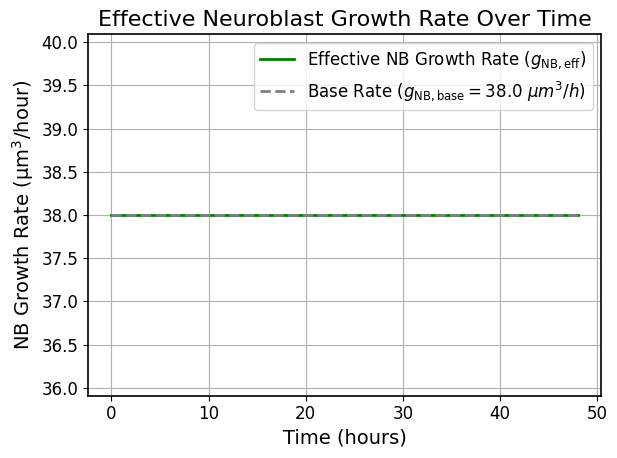

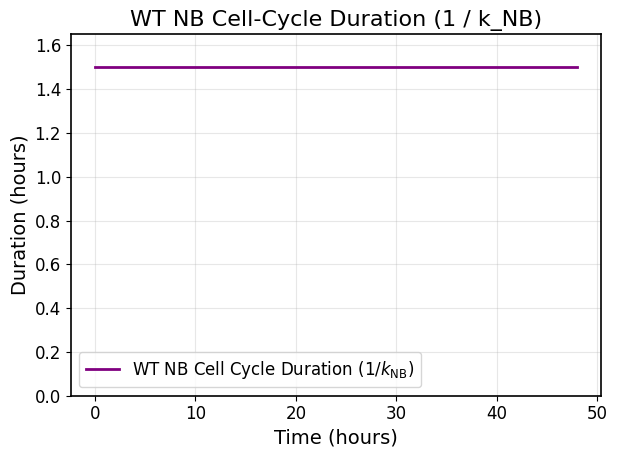

In [167]:
nb_vol = 285                     # Initial neuroblast volume (µm³)
k_Neuron = 1/48                  # maturation rate of neurons
# --- WT target constants ---
V0 = nb_vol                      # target NB average volume (keep constant)
sym_frac = 0.0                   # asymmetric only, keeps N_NB = 1

k_avg_NB  = 1.0 / 1.5            # h^-1

V_ref_NB  = 0.8 * V0             # NB ref = steady NB birth avg
V_ref_GMC = 0.2 * V0             # GMC ref = steady GMC birth avg

g_NB_base = 0.2 * k_avg_NB * V0  # µm^3/h

k_avg_GMC = 1.0 / 9.0            # h^-1
g_GMC     = (nb_vol * 1.2 * 0.2) / 9

alpha_birth_division = 3
alpha_birth_growth   = 3


params_adder_sat = [
    g_NB_base, g_GMC,            # growth rates
    k_Neuron,                    # maturation
    sym_frac,                    # symmetric division fraction
    k_avg_NB, k_avg_GMC,         # base division rates
    alpha_birth_division,        # birth-scaling exponent for division
    V_ref_NB, V_ref_GMC,         # reference birth volumes
    alpha_birth_growth           # birth-scaling exponent for growth
]

# 7) Initial conditions: set NB birth sum so Bavg_NB / V_ref_NB = 1 at t=0
y0 = [1, V0,   0, 0,  0, 0, 0, 0, V_ref_NB, 0.0]

# --- Time integration settings ---
t_span = [0, 48]                            # Simulate 48 hours
t_eval = np.linspace(*t_span, 500)         # Evaluate at 500 evenly spaced points

# --- Solve ---
sol_adder = solve_ivp(
    neuroblast_model_volume_powerlaw_birth_diffs,
    t_span, y0, t_eval=t_eval, args=(params_adder_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_adder.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_adder.t, y, label=label)

ax.set_xlim(0, sol_adder.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_adder.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("WT Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Division Rate)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: Birth Volume vs V_ref ==========

# Compute average birth volumes
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0], out=np.zeros_like(sol_adder.y[8]), where=sol_adder.y[0] > 0)
Bavg_GMC = np.divide(sol_adder.y[9], sol_adder.y[2], out=np.zeros_like(sol_adder.y[9]), where=sol_adder.y[2] > 0)

fig, ax = plt.subplots()
ax.plot(sol_adder.t, Bavg_NB, label=r"$\bar{B}_{\mathrm{NB}}$", linewidth=2)
ax.hlines(V_ref_NB, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"$V_{{\mathrm{{ref,NB}}}} = {V_ref_NB:.0f}\ \mu m^3$")

ax.plot(sol_adder.t, Bavg_GMC, label=r"$\bar{B}_{\mathrm{GMC}}$", linewidth=2, color="tab:orange")
ax.hlines(V_ref_GMC, sol_adder.t[0], sol_adder.t[-1], linestyles="--", color="tab:orange",
          label=rf"$V_{{\mathrm{{ref,GMC}}}} = {V_ref_GMC:.0f}\ \mu m^3$")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Birth Volume (µm$^3$)")
ax.set_title("Average Birth Volume vs Reference Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB Effective Growth Rate Over Time ==========
g_NB_eff_series = g_NB_base * np.power(
    np.divide(Bavg_NB, V_ref_NB, out=np.zeros_like(Bavg_NB), where=V_ref_NB > 0),
    alpha_birth_growth
)
fig, ax = plt.subplots()
ax.plot(sol_adder.t, g_NB_eff_series, label=r"Effective NB Growth Rate ($g_{\mathrm{NB,eff}}$)", color="green", linewidth=2)
ax.hlines(g_NB_base, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"Base Rate ($g_{{\mathrm{{NB,base}}}} = {g_NB_base:.1f}\ \mu m^3/h$)", color="gray")

ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"NB Growth Rate (µm$^3$/hour)")
ax.set_title("Effective Neuroblast Growth Rate Over Time")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 4: NB cell-cycle duration ==========
# Compute NB division rate using power-law function of birth volume
k_NB_series = k_avg_NB * np.power(
    np.divide(Bavg_NB, V_ref_NB, out=np.zeros_like(Bavg_NB), where=V_ref_NB > 0),
    alpha_birth_division
)

# Cell cycle duration is inverse of division rate
ccd_hazard = np.divide(1.0, k_NB_series, out=np.full_like(k_NB_series, np.nan), where=k_NB_series > 0)

# Plot
fig, ax = plt.subplots()
ax.plot(sol_adder.t, ccd_hazard, color="purple", linewidth=2,
        label=r"WT NB Cell Cycle Duration ($1/k_{\mathrm{NB}}$)")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, np.nanmax(ccd_hazard) * 1.1)
ax.set_title("WT NB Cell-Cycle Duration (1 / k_NB)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


mudmut simulation

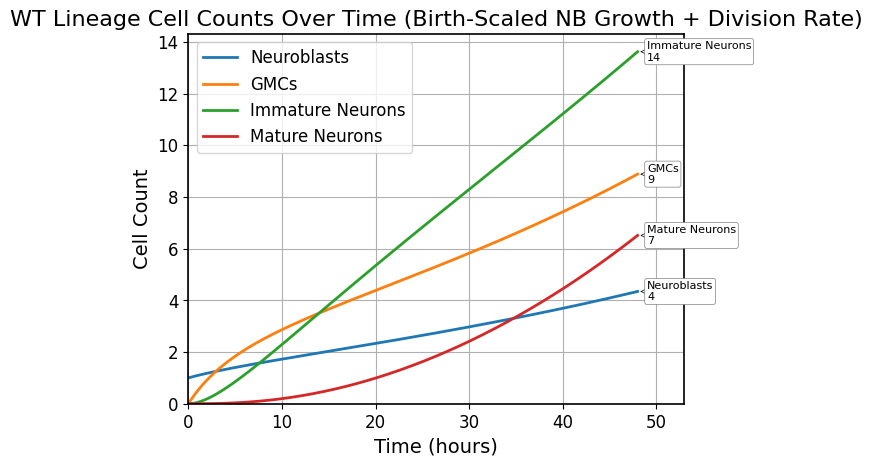

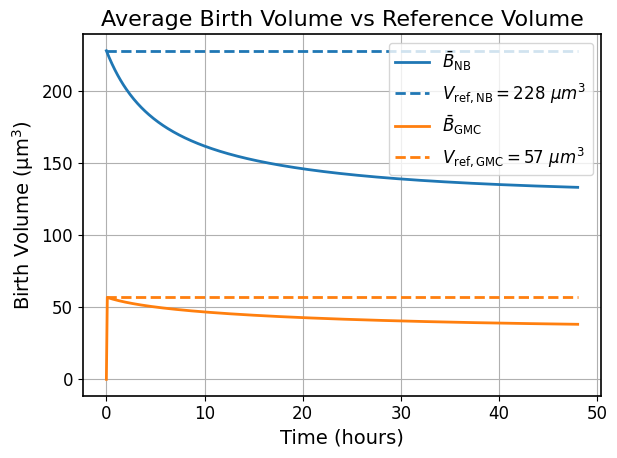

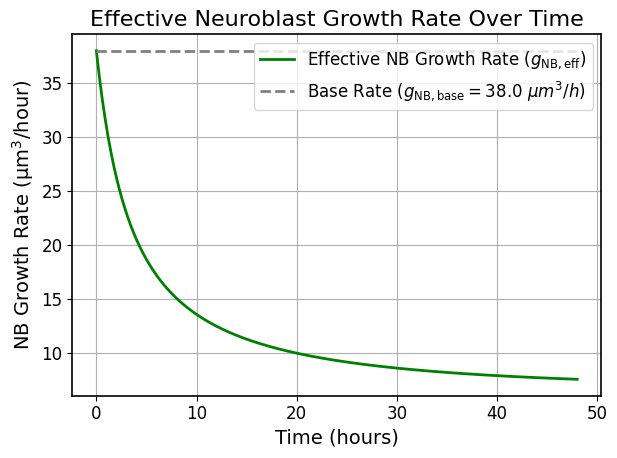

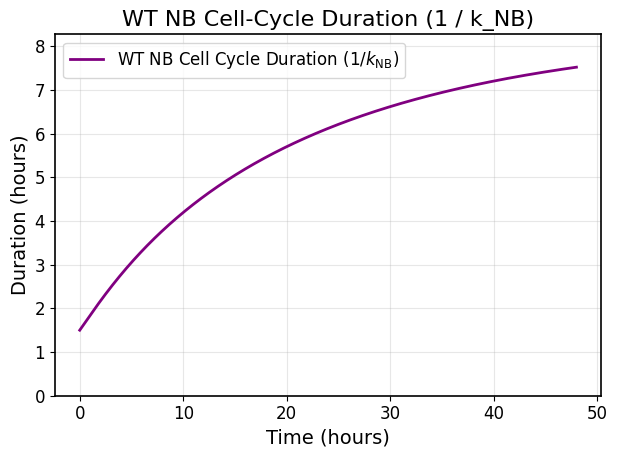

In [168]:
sym_frac = 0.15

params_adder_sat = [
    g_NB_base, g_GMC,            # growth rates
    k_Neuron,                    # maturation
    sym_frac,                    # symmetric division fraction
    k_avg_NB, k_avg_GMC,         # base division rates
    alpha_birth_division,        # birth-scaling exponent for division
    V_ref_NB, V_ref_GMC,         # reference birth volumes
    alpha_birth_growth           # birth-scaling exponent for growth
]
y0 = [1, V0,   0, 0,  0, 0, 0, 0, V_ref_NB, 0.0]

# --- Time integration settings ---
t_span = [0, 48]                            # Simulate 48 hours
t_eval = np.linspace(*t_span, 500)         # Evaluate at 500 evenly spaced points

# --- Solve ---
sol_adder = solve_ivp(
    neuroblast_model_volume_powerlaw_birth_diffs,
    t_span, y0, t_eval=t_eval, args=(params_adder_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_adder.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_adder.t, y, label=label)

ax.set_xlim(0, sol_adder.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_adder.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("WT Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Division Rate)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: Birth Volume vs V_ref ==========

# Compute average birth volumes
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0], out=np.zeros_like(sol_adder.y[8]), where=sol_adder.y[0] > 0)
Bavg_GMC = np.divide(sol_adder.y[9], sol_adder.y[2], out=np.zeros_like(sol_adder.y[9]), where=sol_adder.y[2] > 0)

fig, ax = plt.subplots()
ax.plot(sol_adder.t, Bavg_NB, label=r"$\bar{B}_{\mathrm{NB}}$", linewidth=2)
ax.hlines(V_ref_NB, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"$V_{{\mathrm{{ref,NB}}}} = {V_ref_NB:.0f}\ \mu m^3$")

ax.plot(sol_adder.t, Bavg_GMC, label=r"$\bar{B}_{\mathrm{GMC}}$", linewidth=2, color="tab:orange")
ax.hlines(V_ref_GMC, sol_adder.t[0], sol_adder.t[-1], linestyles="--", color="tab:orange",
          label=rf"$V_{{\mathrm{{ref,GMC}}}} = {V_ref_GMC:.0f}\ \mu m^3$")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Birth Volume (µm$^3$)")
ax.set_title("Average Birth Volume vs Reference Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB Effective Growth Rate Over Time ==========
g_NB_eff_series = g_NB_base * np.power(
    np.divide(Bavg_NB, V_ref_NB, out=np.zeros_like(Bavg_NB), where=V_ref_NB > 0),
    alpha_birth_growth
)
fig, ax = plt.subplots()
ax.plot(sol_adder.t, g_NB_eff_series, label=r"Effective NB Growth Rate ($g_{\mathrm{NB,eff}}$)", color="green", linewidth=2)
ax.hlines(g_NB_base, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"Base Rate ($g_{{\mathrm{{NB,base}}}} = {g_NB_base:.1f}\ \mu m^3/h$)", color="gray")

ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"NB Growth Rate (µm$^3$/hour)")
ax.set_title("Effective Neuroblast Growth Rate Over Time")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 4: NB cell-cycle duration ==========
# Compute NB division rate using power-law function of birth volume
k_NB_series = k_avg_NB * np.power(
    np.divide(Bavg_NB, V_ref_NB, out=np.zeros_like(Bavg_NB), where=V_ref_NB > 0),
    alpha_birth_division
)

# Cell cycle duration is inverse of division rate
ccd_hazard = np.divide(1.0, k_NB_series, out=np.full_like(k_NB_series, np.nan), where=k_NB_series > 0)

# Plot
fig, ax = plt.subplots()
ax.plot(sol_adder.t, ccd_hazard, color="purple", linewidth=2,
        label=r"WT NB Cell Cycle Duration ($1/k_{\mathrm{NB}}$)")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, np.nanmax(ccd_hazard) * 1.1)
ax.set_title("WT NB Cell-Cycle Duration (1 / k_NB)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


nanobody simulation

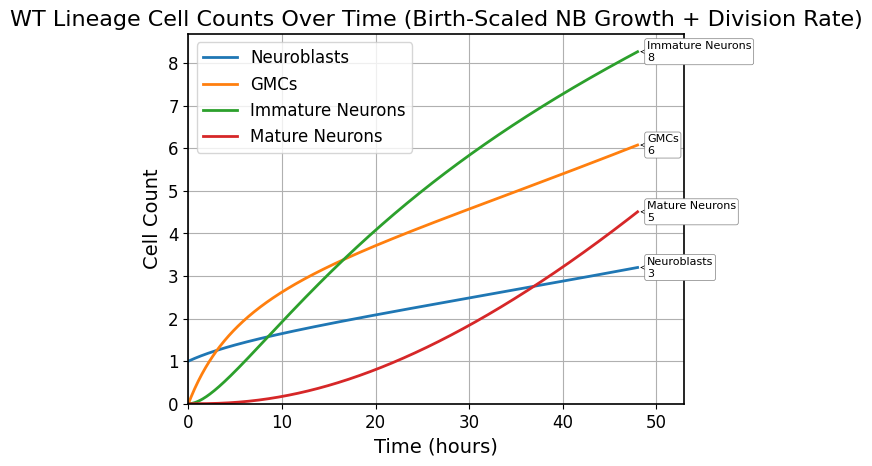

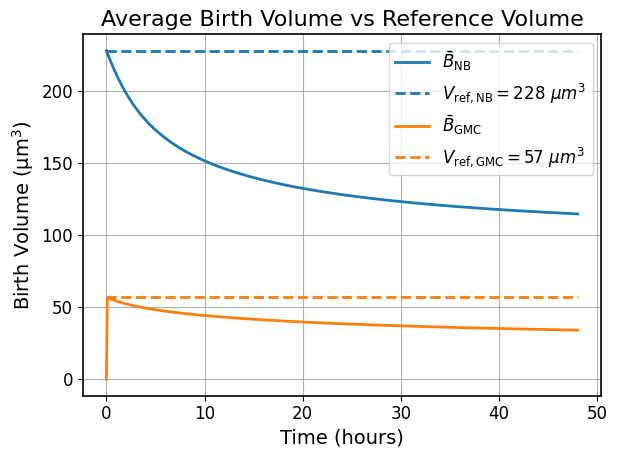

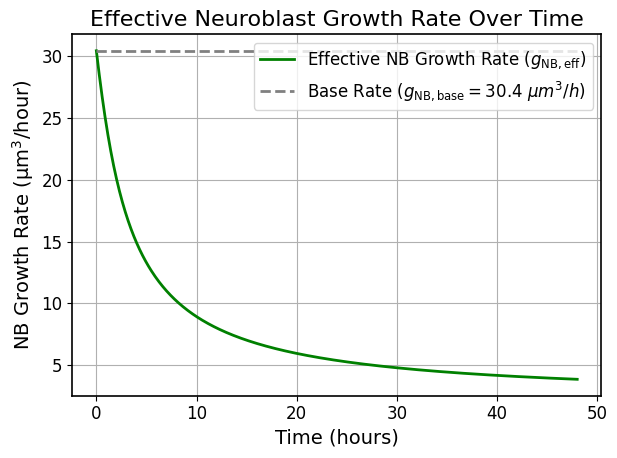

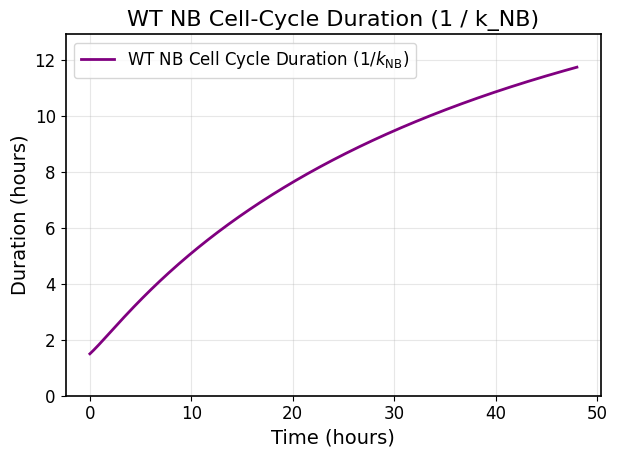

In [169]:
sym_frac = 0.15
WT_g_NB_base = g_NB_base
g_NB_base = WT_g_NB_base*.8

params_adder_sat = [
    g_NB_base, g_GMC,            # growth rates
    k_Neuron,                    # maturation
    sym_frac,                    # symmetric division fraction
    k_avg_NB, k_avg_GMC,         # base division rates
    alpha_birth_division,        # birth-scaling exponent for division
    V_ref_NB, V_ref_GMC,         # reference birth volumes
    alpha_birth_growth           # birth-scaling exponent for growth
]
y0 = [1, V0,   0, 0,  0, 0, 0, 0, V_ref_NB, 0.0]

# --- Time integration settings ---
t_span = [0, 48]                            # Simulate 48 hours
t_eval = np.linspace(*t_span, 500)         # Evaluate at 500 evenly spaced points

# --- Solve ---
sol_adder = solve_ivp(
    neuroblast_model_volume_powerlaw_birth_diffs,
    t_span, y0, t_eval=t_eval, args=(params_adder_sat,),
    rtol=1e-6, atol=1e-9
)

# ========== Plot 1: Cell counts ==========
fig, ax = plt.subplots()
labels  = ["Neuroblasts", "GMCs", "Immature Neurons", "Mature Neurons"]
indices = [0, 2, 4, 6]
y_data  = [sol_adder.y[i] for i in indices]

for y, label in zip(y_data, labels):
    ax.plot(sol_adder.t, y, label=label)

ax.set_xlim(0, sol_adder.t[-1] + 5)
ax.set_ylim(bottom=0)
try:
    annotate_final_values(ax, sol_adder.t, y_data, labels)
except NameError:
    pass
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cell Count")
ax.set_title("WT Lineage Cell Counts Over Time (Birth-Scaled NB Growth + Division Rate)")
ax.grid()
ax.legend()
plt.show()

# ========== Plot 2: Birth Volume vs V_ref ==========

# Compute average birth volumes
Bavg_NB = np.divide(sol_adder.y[8], sol_adder.y[0], out=np.zeros_like(sol_adder.y[8]), where=sol_adder.y[0] > 0)
Bavg_GMC = np.divide(sol_adder.y[9], sol_adder.y[2], out=np.zeros_like(sol_adder.y[9]), where=sol_adder.y[2] > 0)

fig, ax = plt.subplots()
ax.plot(sol_adder.t, Bavg_NB, label=r"$\bar{B}_{\mathrm{NB}}$", linewidth=2)
ax.hlines(V_ref_NB, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"$V_{{\mathrm{{ref,NB}}}} = {V_ref_NB:.0f}\ \mu m^3$")

ax.plot(sol_adder.t, Bavg_GMC, label=r"$\bar{B}_{\mathrm{GMC}}$", linewidth=2, color="tab:orange")
ax.hlines(V_ref_GMC, sol_adder.t[0], sol_adder.t[-1], linestyles="--", color="tab:orange",
          label=rf"$V_{{\mathrm{{ref,GMC}}}} = {V_ref_GMC:.0f}\ \mu m^3$")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Birth Volume (µm$^3$)")
ax.set_title("Average Birth Volume vs Reference Volume")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 3: NB Effective Growth Rate Over Time ==========
g_NB_eff_series = g_NB_base * np.power(
    np.divide(Bavg_NB, V_ref_NB, out=np.zeros_like(Bavg_NB), where=V_ref_NB > 0),
    alpha_birth_growth
)
fig, ax = plt.subplots()
ax.plot(sol_adder.t, g_NB_eff_series, label=r"Effective NB Growth Rate ($g_{\mathrm{NB,eff}}$)", color="green", linewidth=2)
ax.hlines(g_NB_base, sol_adder.t[0], sol_adder.t[-1], linestyles="--",
          label=rf"Base Rate ($g_{{\mathrm{{NB,base}}}} = {g_NB_base:.1f}\ \mu m^3/h$)", color="gray")

ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"NB Growth Rate (µm$^3$/hour)")
ax.set_title("Effective Neuroblast Growth Rate Over Time")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 4: NB cell-cycle duration ==========
# Compute NB division rate using power-law function of birth volume
k_NB_series = k_avg_NB * np.power(
    np.divide(Bavg_NB, V_ref_NB, out=np.zeros_like(Bavg_NB), where=V_ref_NB > 0),
    alpha_birth_division
)

# Cell cycle duration is inverse of division rate
ccd_hazard = np.divide(1.0, k_NB_series, out=np.full_like(k_NB_series, np.nan), where=k_NB_series > 0)

# Plot
fig, ax = plt.subplots()
ax.plot(sol_adder.t, ccd_hazard, color="purple", linewidth=2,
        label=r"WT NB Cell Cycle Duration ($1/k_{\mathrm{NB}}$)")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Duration (hours)")
ax.set_ylim(0, np.nanmax(ccd_hazard) * 1.1)
ax.set_title("WT NB Cell-Cycle Duration (1 / k_NB)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
